In [1]:
# Import all required libraries
import numpy as np
import struct
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error
import pandas as pd
import os

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("All imports successful")

All imports successful


In [2]:
#  Define functions to load Fashion-MNIST from ubyte filesimport torch.optim as optim

def load_mnist_images(file_path):
    
    """
    Load images from ubyte file format used by MNIST/Fashion-MNIST
    """
    with open(file_path, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        if magic != 2051:
            raise ValueError(f"Invalid magic number {magic}")
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num_images, rows, cols)
        images = images.astype(np.float32) / 255.0
    return images

def load_mnist_labels(file_path):
    """
    Load labels from ubyte file format used by MNIST/Fashion-MNIST
    """
    with open(file_path, 'rb') as f:
        magic, num_labels = struct.unpack(">II", f.read(8))
        if magic != 2049:
            raise ValueError(f"Invalid magic number {magic}")
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

print("Fashion-MNIST loader functions defined")

Fashion-MNIST loader functions defined


In [3]:
# Load Fashion-MNIST training and test data
print("Loading Fashion-MNIST...")

train_images_path = "data/fashion-mnist/train-images-idx3-ubyte"
train_labels_path = "data/fashion-mnist/train-labels-idx1-ubyte"
test_images_path = "data/fashion-mnist/t10k-images-idx3-ubyte"
test_labels_path = "data/fashion-mnist/t10k-labels-idx1-ubyte"

train_images = load_mnist_images(train_images_path)
train_labels = load_mnist_labels(train_labels_path)
test_images = load_mnist_images(test_images_path)
test_labels = load_mnist_labels(test_labels_path)

print(f"Training images shape: {train_images.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")

Loading Fashion-MNIST...
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


In [4]:
#  Convert Fashion-MNIST numpy arrays to PyTorch tensors and create DataLoaders
print("Converting Fashion-MNIST to PyTorch format...")


# Convert to tensors
train_images_tensor = torch.FloatTensor(train_images).unsqueeze(1)
test_images_tensor = torch.FloatTensor(test_images).unsqueeze(1)
train_labels_tensor = torch.LongTensor(train_labels)
test_labels_tensor = torch.LongTensor(test_labels)

# Create datasets
train_dataset = TensorDataset(train_images_tensor, train_labels_tensor)
test_dataset = TensorDataset(test_images_tensor, test_labels_tensor)

# Create data loaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train loader: {len(train_loader)} batches of size {batch_size}")
print(f"Test loader: {len(test_loader)} batches of size {batch_size}")

Converting Fashion-MNIST to PyTorch format...
Train loader: 938 batches of size 64
Test loader: 157 batches of size 64


/var/folders/3b/7gmjvzm941n051v80wkt29cr0000gn/T/ipykernel_18072/2195957763.py:8: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1744320376245/work/torch/csrc/utils/tensor_numpy.cpp:212.)
  train_labels_tensor = torch.LongTensor(train_labels)


In [5]:
#  Define functions to load notMNIST data for OOD testing
def load_ubyte_images(file_path):

    """
    Load images from ubyte file for notMNIST
    Normalizes pixel values to [0, 1] to match Fashion-MNIST preprocessing
    """
    with open(file_path, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        if magic != 2051:
            raise ValueError(f"Invalid magic number {magic}")
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num_images, rows, cols)
        # FIX: Normalize to [0, 1] to match Fashion-MNIST
        images = images.astype(np.float32) / 255.0
    return images


def load_ubyte_labels(file_path):
    """
    Load labels from ubyte file for notMNIST
    """
    with open(file_path, 'rb') as f:
        magic, num_labels = struct.unpack(">II", f.read(8))
        if magic != 2049:
            raise ValueError(f"Invalid magic number {magic}")
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

print("notMNIST loader functions defined")

notMNIST loader functions defined


In [6]:
# Load notMNIST data for OOD detection (Task 3)
print("Loading notMNIST...")


notmnist_images_path = "data/notMNIST/notmnist-images-idx3-ubyte"
notmnist_labels_path = "data/notMNIST/notmnist-labels-idx1-ubyte"

notmnist_images = load_ubyte_images(notmnist_images_path)
notmnist_labels = load_ubyte_labels(notmnist_labels_path)

# Convert to PyTorch tensors
notmnist_images_tensor = torch.FloatTensor(notmnist_images).unsqueeze(1)
notmnist_labels_tensor = torch.LongTensor(notmnist_labels)

# Create data loader
notmnist_dataset = TensorDataset(notmnist_images_tensor, notmnist_labels_tensor)
notmnist_loader = DataLoader(notmnist_dataset, batch_size=64, shuffle=False)

print(f"notMNIST images shape: {notmnist_images.shape}")
print(f"notMNIST labels shape: {notmnist_labels.shape}")
print(f"notMNIST loader: {len(notmnist_loader)} batches")

Loading notMNIST...
notMNIST images shape: (18724, 28, 28)
notMNIST labels shape: (18724,)
notMNIST loader: 293 batches


In [7]:
# Load UCI Energy dataset from local file

print("Loading UCI Energy dataset...")

# Use your local file path
file_path = "data/ENB2012_data.xlsx"
df = pd.read_excel(file_path, engine='openpyxl')

# Features (X1 to X8) and target (Y1 - Heating Load)
X = df.iloc[:, 0:8].values
y = df.iloc[:, 8].values.reshape(-1, 1)  # Reshape for scaler

print(f"Dataset shape: {X.shape}")
print(f"Original target range: {y.min():.2f} to {y.max():.2f}")

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (X)
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

# Standardize targets (y) as well
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train).flatten()
y_test = scaler_y.transform(y_test).flatten()

print(f"Standardized target range: {y_train.min():.2f} to {y_train.max():.2f}")
print(f"Standard deviation of targets: {scaler_y.scale_[0]:.4f}")

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)

# Create data loaders
uci_train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
uci_test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32, shuffle=False)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Train loader: {len(uci_train_loader)} batches")
print(f"Test loader: {len(uci_test_loader)} batches")

Loading UCI Energy dataset...
Dataset shape: (768, 8)
Original target range: 6.01 to 43.10
Standardized target range: -1.61 to 2.08
Standard deviation of targets: 10.0461
Training samples: 614
Test samples: 154
Train loader: 20 batches
Test loader: 5 batches


In [8]:
# Task 1a - Define Dropout Network for Classification
# This network will be used for Fashion-MNIST classification
# Dropout layers are used during both training AND testing

class MCDropoutClassifier(nn.Module):
    """
    Neural network for classification with dropout layers.
    Dropout remains active at test time for Monte Carlo sampling.
    """
    def __init__(self, input_size=784, hidden_size=256, num_classes=10, dropout_rate=0.5):
        """
        Args:
            input_size: 28x28 = 784 pixels flattened
            hidden_size: number of neurons in hidden layers
            num_classes: 10 clothing categories
            dropout_rate: probability of dropping neurons (0.5 = 50%)
        """
        super(MCDropoutClassifier, self).__init__()
        
        # First hidden layer: 784 -> 256
        self.fc1 = nn.Linear(input_size, hidden_size)
        
        # Second hidden layer: 256 -> 256
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        
        # Output layer: 256 -> 10 classes
        self.fc3 = nn.Linear(hidden_size, num_classes)
        
        # Dropout layer for regularization and uncertainty estimation
        self.dropout = nn.Dropout(dropout_rate)
        
    def forward(self, x):
        # Flatten the 28x28 image to 784-dimensional vector
        x = x.view(x.size(0), -1)
        
        # First hidden layer with ReLU activation
        x = F.relu(self.fc1(x))
        
        # Apply dropout after first hidden layer
        x = self.dropout(x)
        
        # Second hidden layer with ReLU activation
        x = F.relu(self.fc2(x))
        
        # Apply dropout after second hidden layer
        x = self.dropout(x)
        
        # Output layer (logits, no softmax here)
        x = self.fc3(x)
        return x

print("Task 1a: Dropout classifier defined")

Task 1a: Dropout classifier defined


In [9]:
# Task 1a - Define Dropout Network for Regression
# This network will be used for UCI Energy dataset
# Predicts both mean AND variance 

class MCDropoutRegressor(nn.Module):
    """
    Neural network for regression with dropout layers.
    Outputs both mean and variance for each input.
    """
    def __init__(self, input_size=8, hidden_size=64, dropout_rate=0.3):
        """
        Args:
            input_size: 8 features from UCI dataset
            hidden_size: number of neurons in hidden layers
            dropout_rate: probability of dropping neurons (0.3 = 30%)
        """
        super(MCDropoutRegressor, self).__init__()
        
        # First hidden layer: 8 -> 64
        self.fc1 = nn.Linear(input_size, hidden_size)
        
        # Second hidden layer: 64 -> 64
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        
        # Output layer for mean prediction
        self.fc_mean = nn.Linear(hidden_size, 1)
        
        # Output layer for variance prediction (log variance then softplus)
        self.fc_var = nn.Linear(hidden_size, 1)
        
        # Dropout layer
        self.dropout = nn.Dropout(dropout_rate)
        
    def forward(self, x):
        # First hidden layer with ReLU
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        
        # Second hidden layer with ReLU
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        
        # Mean prediction (no activation, can be any real number)
        mean = self.fc_mean(x)
        
        # Variance prediction (softplus ensures variance is positive)
        var = F.softplus(self.fc_var(x))
        
        return mean, var

print("Task 1a: Dropout regressor defined")

Task 1a: Dropout regressor defined


In [10]:
# Task 1a - MC-Dropout Prediction Function
# This function keeps dropout active at test time
# Runs multiple forward passes to estimate mean and variance

def mc_dropout_predict_classifier(model, x, num_passes=50):
    """
    Monte Carlo Dropout prediction for classification.
    
    Args:
        model: neural network with dropout layers
        x: input images
        num_passes: number of forward passes (parameter)
    
    Returns:
        mean: average prediction across all passes
        variance: uncertainty estimate across passes
    """
    # Set model to train mode to KEEP DROPOUT ACTIVE
    # This is the key requirement for MC-Dropout
    model.train()
    
    predictions = []
    
    # Disable gradient computation for efficiency
    with torch.no_grad():
        for _ in range(num_passes):
            # Forward pass with dropout active
            output = model(x)
            
            # Convert logits to probabilities
            pred = F.softmax(output, dim=1)
            predictions.append(pred)
    
    # Stack all predictions: shape (num_passes, batch_size, num_classes)
    predictions = torch.stack(predictions)
    
    # Mean prediction across all passes
    mean = predictions.mean(dim=0)
    
    # Variance across passes (epistemic uncertainty)
    variance = predictions.var(dim=0)
    
    return mean, variance

def mc_dropout_predict_regressor(model, x, num_passes=50):
    """
    Monte Carlo Dropout prediction for regression.
    
    Returns:
        mean: predictive mean
        variance: total uncertainty (aleatoric + epistemic)
    """
    # Keep dropout active
    model.train()
    
    means = []
    variances = []
    
    with torch.no_grad():
        for _ in range(num_passes):
            mean, var = model(x)
            means.append(mean)
            variances.append(var)
    
    # Stack results
    means = torch.stack(means)
    variances = torch.stack(variances)
    
    # Predictive mean = average of means
    pred_mean = means.mean(dim=0)
    
    # Total uncertainty = aleatoric (mean variance) + epistemic (variance of means)
    pred_variance = variances.mean(dim=0) + means.var(dim=0)
    
    return pred_mean, pred_variance

print("Task 1a: MC-Dropout prediction functions defined")
print("Requirements satisfied:")
print("  - Dropout layers in neural network: YES")
print("  - Dropout active at test time: YES (model.train() used)")
print("  - Multiple passes as parameter: YES (num_passes argument)")

Task 1a: MC-Dropout prediction functions defined
Requirements satisfied:
  - Dropout layers in neural network: YES
  - Dropout active at test time: YES (model.train() used)
  - Multiple passes as parameter: YES (num_passes argument)


In [11]:
#  Task 1b - Deep Ensembles Implementation


def train_ensemble_member_classifier(train_loader, input_size=784, hidden_size=256, 
                                      num_classes=10, num_epochs=10, lr=0.001, model_id=1):
    """
    Train a single classifier model for the ensemble.
    
    Key point: Each model is initialized with DIFFERENT random weights
    because PyTorch initializes weights randomly when model is created.
    No need to manually set different seeds - each call creates different weights.
    """
    # Create a NEW model with fresh random initialization
    model = MCDropoutClassifier(
        input_size=input_size, 
        hidden_size=hidden_size, 
        num_classes=num_classes, 
        dropout_rate=0.5
    )
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    print(f"  Training model {model_id}/5...")
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        # Print progress every 5 epochs
        if (epoch + 1) % 5 == 0:
            avg_loss = total_loss / len(train_loader)
            print(f"    Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")
    
    return model

def train_ensemble_member_regressor(train_loader, input_size=8, hidden_size=64, 
                                     num_epochs=100, lr=0.001, model_id=1):
    """
    Train a single regressor model for the ensemble.
    Each model gets different random initialization.
    """
    # Create a NEW model with fresh random initialization
    model = MCDropoutRegressor(
        input_size=input_size, 
        hidden_size=hidden_size, 
        dropout_rate=0.3
    )
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    def nll_loss(mean, var, target):
        """Gaussian negative log-likelihood loss"""
        var = var + 1e-6  # Small epsilon for numerical stability
        return 0.5 * ((target - mean)**2 / var + torch.log(var)).mean()
    
    print(f"  Training regressor {model_id}/5...")
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        
        for x, y in train_loader:
            optimizer.zero_grad()
            mean, var = model(x)
            loss = nll_loss(mean, var, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        # Print progress every 20 epochs
        if (epoch + 1) % 20 == 0:
            avg_loss = total_loss / len(train_loader)
            print(f"    Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")
    
    return model

def create_deep_ensemble_classifier(train_loader, k=5, num_epochs=10):
    """
    Create an ensemble of k classifier models.
    
    Args:
        train_loader: data loader for training
        k: number of models in ensemble (set to 5 per assignment)
        num_epochs: epochs to train each model
    
    Returns:
        models: list of k trained models
    """
    print(f"\nCreating Deep Ensemble with {k} classifiers...")
    print("Each model has different random initialization")
    print("-" * 40)
    
    models = []
    
    for i in range(k):
        model = train_ensemble_member_classifier(
            train_loader, 
            num_epochs=num_epochs, 
            model_id=i+1
        )
        models.append(model)
    
    print("-" * 40)
    print(f"Ensemble created with {len(models)} models")
    
    return models

def create_deep_ensemble_regressor(train_loader, k=5, num_epochs=100):
    """
    Create an ensemble of k regressor models.
    
    Args:
        train_loader: data loader for training
        k: number of models in ensemble (set to 5 per assignment)
        num_epochs: epochs to train each model
    
    Returns:
        models: list of k trained models
    """
    print(f"\nCreating Deep Ensemble with {k} regressors...")
    print("Each model has different random initialization")
    print("-" * 40)
    
    models = []
    
    for i in range(k):
        model = train_ensemble_member_regressor(
            train_loader, 
            num_epochs=num_epochs, 
            model_id=i+1
        )
        models.append(model)
    
    print("-" * 40)
    print(f"Ensemble created with {len(models)} models")
    
    return models

def ensemble_predict_classifier(models, x):
    """
    Make predictions using ensemble of classifiers.
    
    Args:
        models: list of trained models
        x: input images
    
    Returns:
        mean: average probability across all models
        variance: variance across models (epistemic uncertainty)
    """
    all_predictions = []
    
    for model in models:
        model.eval()  # Evaluation mode (dropout OFF for ensemble)
        with torch.no_grad():
            outputs = model(x)
            probs = F.softmax(outputs, dim=1)
            all_predictions.append(probs)
    
    # Stack predictions from all models
    all_predictions = torch.stack(all_predictions)
    
    # Mean across ensemble members
    mean = all_predictions.mean(dim=0)
    
    # Variance across ensemble members (epistemic uncertainty)
    variance = all_predictions.var(dim=0)
    
    return mean, variance

def ensemble_predict_regressor(models, x):
    """
    Make predictions using ensemble of regressors.
    
    Returns:
        mean: average prediction across all models
        variance: total uncertainty (aleatoric + epistemic)
    """
    all_means = []
    all_vars = []
    
    for model in models:
        model.eval()
        with torch.no_grad():
            mean, var = model(x)
            all_means.append(mean)
            all_vars.append(var)
    
    # Stack results
    all_means = torch.stack(all_means)
    all_vars = torch.stack(all_vars)
    
    # Predictive mean = average of means
    pred_mean = all_means.mean(dim=0)
    
    # Total uncertainty = aleatoric (mean variance) + epistemic (variance of means)
    pred_variance = all_vars.mean(dim=0) + all_means.var(dim=0)
    
    return pred_mean, pred_variance


print("Task 1b: Deep Ensembles Implemented")
print("Requirements satisfied:")
print("  - k independently initialized models (with k=5 parameter)")
print("  - Same architecture for all models")
print("  - Ensemble predictions with mean and variance")


Task 1b: Deep Ensembles Implemented
Requirements satisfied:
  - k independently initialized models (with k=5 parameter)
  - Same architecture for all models
  - Ensemble predictions with mean and variance


In [12]:
#  Task 1c - Train MC-Dropout Regressor on UCI Dataset
# This trains the dropout model to predict heating load with uncertainty

def train_mc_dropout_regressor(train_loader, test_loader, num_epochs=100, lr=0.001):
    """
    Train the MC-Dropout regressor on UCI Energy dataset.
    
    Loss function: Gaussian Negative Log-Likelihood (NLL)
    This loss allows the model to learn both mean and variance.
    """
    # Create new model instance
    model = MCDropoutRegressor(input_size=8, hidden_size=64, dropout_rate=0.3)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    def gaussian_nll_loss(mean, var, target):
        """
        Gaussian negative log-likelihood loss.
        
        Formula: 0.5 * ((y - mean)^2 / var + log(var))
        Lower loss means better mean prediction AND better variance estimation.
        """
        var = var + 1e-6  # Prevent division by zero
        loss = 0.5 * ((target - mean)**2 / var + torch.log(var))
        return loss.mean()
    
    train_losses = []
    
    print("Training MC-Dropout Regressor on UCI Dataset")
    
    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        
        for x, y in train_loader:
            optimizer.zero_grad()
            mean, var = model(x)
            loss = gaussian_nll_loss(mean, var, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        # Print progress every 20 epochs
        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")
    
    print("Training completed")
    return model, train_losses

# Train the MC-Dropout model
print("\nStarting MC-Dropout training...")
mc_regressor, mc_train_losses = train_mc_dropout_regressor(
    uci_train_loader, uci_test_loader, num_epochs=100, lr=0.001
)
print("MC-Dropout regressor ready")


Starting MC-Dropout training...
Training MC-Dropout Regressor on UCI Dataset
Epoch [20/100], Loss: -0.7264
Epoch [40/100], Loss: -0.7332
Epoch [60/100], Loss: -0.8800
Epoch [80/100], Loss: -0.9502
Epoch [100/100], Loss: -0.9746
Training completed
MC-Dropout regressor ready


In [13]:
# Task 1c - Evaluate MC-Dropout on UCI Test Set
# Computes RMSE, Negative Log-Likelihood, and ECE

def evaluate_mc_dropout_regressor(model, test_loader, num_passes=50):
    """
    Evaluate MC-Dropout regressor with multiple forward passes.
    
    Returns:
        - RMSE: Root Mean Square Error (lower is better)
        - NLL: Negative Log-Likelihood (lower is better)
        - ECE: Expected Calibration Error for regression (lower is better)
    """
    model.train()  # Keep dropout active for MC sampling
    
    all_pred_means = []
    all_pred_vars = []
    all_targets = []
    
    print(f"\nRunning {num_passes} Monte Carlo forward passes...")
    
    with torch.no_grad():
        for x, y in test_loader:
            pred_mean, pred_var = mc_dropout_predict_regressor(model, x, num_passes)
            all_pred_means.append(pred_mean)
            all_pred_vars.append(pred_var)
            all_targets.append(y)
    
    # Concatenate all batches
    pred_means = torch.cat(all_pred_means, dim=0)
    pred_vars = torch.cat(all_pred_vars, dim=0)
    targets = torch.cat(all_targets, dim=0)
    
    # Convert to numpy for calculations
    pred_means_np = pred_means.squeeze().cpu().numpy()
    pred_vars_np = pred_vars.squeeze().cpu().numpy()
    targets_np = targets.squeeze().cpu().numpy()
    
    # METRIC 1: RMSE 
   # rmse = np.sqrt(np.mean((pred_means_np - targets_np) ** 2))
    rmse_standardized = np.sqrt(np.mean((pred_means_np - targets_np) ** 2))
    # Convert back to original units for reporting
    rmse = rmse_standardized * scaler_y.scale_[0]
    
    # METRIC 2: Negative Log-Likelihood (NLL)
    nll = np.mean(0.5 * ((targets_np - pred_means_np) ** 2 / pred_vars_np + np.log(pred_vars_np + 1e-6)))
    
    # METRIC 3: Expected Calibration Error (ECE) for regression
    # As described 
    # 1. Bin predictions by variance
    # 2. For each bin: compute |MSE - AvgPredVar|
    # 3. Weight by bin size
    n_bins = 15
    n_samples = len(targets_np)
    
    # Create bins based on variance percentiles
    bin_boundaries = np.percentile(pred_vars_np, np.linspace(0, 100, n_bins + 1))
    ece = 0.0
    
    for i in range(n_bins):
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i + 1]
        in_bin = (pred_vars_np > bin_lower) & (pred_vars_np <= bin_upper)
        bin_size = np.sum(in_bin)
        
        if bin_size > 0:
            # Mean Squared Error in this bin
            mse_bin = np.mean((pred_means_np[in_bin] - targets_np[in_bin]) ** 2)
            
            # Average predicted variance in this bin
            avg_var_bin = np.mean(pred_vars_np[in_bin])
            
            # Bin error weighted by bin size
            bin_error = (bin_size / n_samples) * abs(mse_bin - avg_var_bin)
            ece += bin_error
    
    # Print results

    print("MC-DROPOUT REGRESSION RESULTS (UCI DATASET)")
    print(f"Number of Monte Carlo passes: {num_passes}")
    print(f"\nRMSE: {rmse:.4f}")
    print(f"Negative Log-Likelihood (NLL): {nll:.4f}")
    print(f"Expected Calibration Error (ECE): {ece:.6f}")
    
    return pred_means, pred_vars, targets, rmse, nll, ece

# Evaluate MC-Dropout
print("\nEvaluating MC-Dropout on UCI test set...")
mc_pred_means, mc_pred_vars, mc_targets, mc_rmse, mc_nll, mc_ece = evaluate_mc_dropout_regressor(
    mc_regressor, uci_test_loader, num_passes=50
)


Evaluating MC-Dropout on UCI test set...

Running 50 Monte Carlo forward passes...
MC-DROPOUT REGRESSION RESULTS (UCI DATASET)
Number of Monte Carlo passes: 50

RMSE: 2.3853
Negative Log-Likelihood (NLL): -1.0196
Expected Calibration Error (ECE): 0.063077


In [14]:
# Task 1c - Train Deep Ensemble Regressor on UCI Dataset
# Trains 5 independently initialized models


print("TRAINING DEEP ENSEMBLE ON UCI DATASET")

# Create ensemble of 5 regressors
ensemble_regressors = create_deep_ensemble_regressor(
    train_loader=uci_train_loader,
    k=5,
    num_epochs=100
)

print(f"\nDeep Ensemble ready with {len(ensemble_regressors)} models")

TRAINING DEEP ENSEMBLE ON UCI DATASET

Creating Deep Ensemble with 5 regressors...
Each model has different random initialization
----------------------------------------
  Training regressor 1/5...
    Epoch 20/100, Loss: -0.6961
    Epoch 40/100, Loss: -0.8219
    Epoch 60/100, Loss: -0.8610
    Epoch 80/100, Loss: -0.9356
    Epoch 100/100, Loss: -0.9719
  Training regressor 2/5...
    Epoch 20/100, Loss: -0.7040
    Epoch 40/100, Loss: -0.7857
    Epoch 60/100, Loss: -0.8921
    Epoch 80/100, Loss: -0.9215
    Epoch 100/100, Loss: -0.9895
  Training regressor 3/5...
    Epoch 20/100, Loss: -0.6351
    Epoch 40/100, Loss: -0.7118
    Epoch 60/100, Loss: -0.9005
    Epoch 80/100, Loss: -0.9580
    Epoch 100/100, Loss: -0.9605
  Training regressor 4/5...
    Epoch 20/100, Loss: -0.6792
    Epoch 40/100, Loss: -0.8503
    Epoch 60/100, Loss: -0.8733
    Epoch 80/100, Loss: -0.9132
    Epoch 100/100, Loss: -1.0463
  Training regressor 5/5...
    Epoch 20/100, Loss: -0.6509
    Epoch 40/

In [15]:
#  Evaluate Deep Ensemble on UCI Test Set
# Computes RMSE, NLL, and ECE for the ensemble

def evaluate_ensemble_regressor(models, test_loader):
    """
    Evaluate ensemble of regression models.
    """
    all_pred_means = []
    all_pred_vars = []
    all_targets = []
    
    print("\nEvaluating Deep Ensemble on UCI test set...")
    
    with torch.no_grad():
        for x, y in test_loader:
            pred_mean, pred_var = ensemble_predict_regressor(models, x)
            all_pred_means.append(pred_mean)
            all_pred_vars.append(pred_var)
            all_targets.append(y)
    
    # Concatenate all batches
    pred_means = torch.cat(all_pred_means, dim=0)
    pred_vars = torch.cat(all_pred_vars, dim=0)
    targets = torch.cat(all_targets, dim=0)
    
    # Convert to numpy
    pred_means_np = pred_means.squeeze().cpu().numpy()
    pred_vars_np = pred_vars.squeeze().cpu().numpy()
    targets_np = targets.squeeze().cpu().numpy()
    
    # Compute RMSE
   # rmse = np.sqrt(np.mean((pred_means_np - targets_np) ** 2))
    rmse_standardized = np.sqrt(np.mean((pred_means_np - targets_np) ** 2))
    # Convert back to original units for reporting
    rmse = rmse_standardized * scaler_y.scale_[0]
    
    # Compute NLL
    nll = np.mean(0.5 * ((targets_np - pred_means_np) ** 2 / pred_vars_np + np.log(pred_vars_np + 1e-6)))
    
    # Compute ECE for regression
    n_bins = 15
    n_samples = len(targets_np)
    bin_boundaries = np.percentile(pred_vars_np, np.linspace(0, 100, n_bins + 1))
    ece = 0.0
    
    for i in range(n_bins):
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i + 1]
        in_bin = (pred_vars_np > bin_lower) & (pred_vars_np <= bin_upper)
        bin_size = np.sum(in_bin)
        
        if bin_size > 0:
            mse_bin = np.mean((pred_means_np[in_bin] - targets_np[in_bin]) ** 2)
            avg_var_bin = np.mean(pred_vars_np[in_bin])
            bin_error = (bin_size / n_samples) * abs(mse_bin - avg_var_bin)
            ece += bin_error
    
    # Print results

    print("DEEP ENSEMBLE REGRESSION RESULTS (UCI DATASET)")
    print(f"Number of ensemble models: {len(models)}")
    print(f"\nRMSE: {rmse:.4f}")
    print(f"Negative Log-Likelihood (NLL): {nll:.4f}")
    print(f"Expected Calibration Error (ECE): {ece:.6f}")

    return pred_means, pred_vars, targets, rmse, nll, ece

# Evaluate Deep Ensemble
ensemble_pred_means, ensemble_pred_vars, ensemble_targets, ensemble_rmse, ensemble_nll, ensemble_ece = evaluate_ensemble_regressor(
    ensemble_regressors, uci_test_loader
)


Evaluating Deep Ensemble on UCI test set...
DEEP ENSEMBLE REGRESSION RESULTS (UCI DATASET)
Number of ensemble models: 5

RMSE: 2.2127
Negative Log-Likelihood (NLL): -1.0933
Expected Calibration Error (ECE): 0.041903


Figure saved to figures/uci_mc_dropout.png


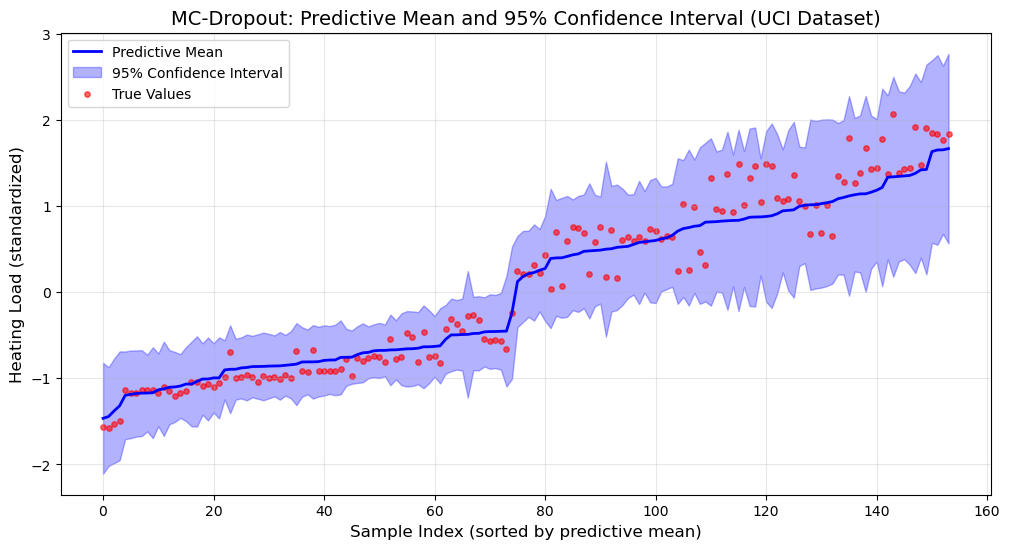

Figure saved to figures/uci_deep_ensemble.png


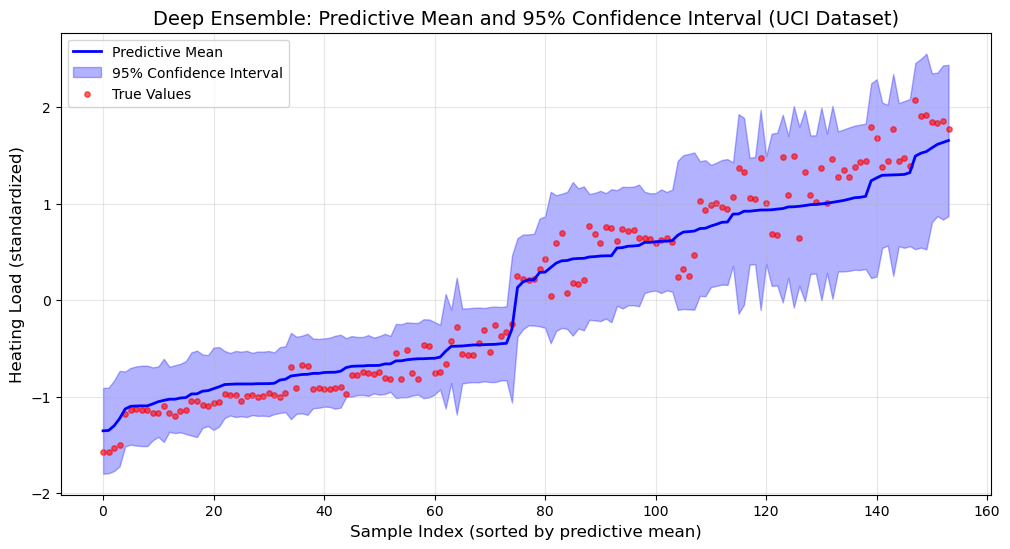

In [16]:
# Task 1c - Plot Predictive Mean and Confidence Intervals

def plot_uci_predictions(pred_means, pred_stds, targets, title, save_name):
    """
    Plot predictive mean with confidence intervals.
    
    Args:
        pred_means: predicted mean values
        pred_stds: predicted standard deviation (sqrt of variance)
        targets: true target values
        title: plot title
        save_name: filename for saving
    """
    # Sort by predictive mean as required
    sort_idx = np.argsort(pred_means.squeeze())
    sorted_means = pred_means[sort_idx].squeeze()
    sorted_stds = pred_stds[sort_idx].squeeze()
    sorted_targets = targets[sort_idx].squeeze()
    
    # X-axis is index after sorting
    x_axis = np.arange(len(sorted_means))
    
    # Create plot
    plt.figure(figsize=(12, 6))
    
    # Predictive mean line
    plt.plot(x_axis, sorted_means, 'b-', label='Predictive Mean', linewidth=2)
    
    # 95% confidence interval (mean +/- 2*std)
    plt.fill_between(x_axis, 
                     sorted_means - 2*sorted_stds, 
                     sorted_means + 2*sorted_stds, 
                     alpha=0.3, color='blue', label='95% Confidence Interval')
    
    # True targets as scatter points
    plt.scatter(x_axis, sorted_targets, c='red', s=15, alpha=0.6, label='True Values')
    
    plt.xlabel('Sample Index (sorted by predictive mean)', fontsize=12)
    plt.ylabel('Heating Load (standardized)', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Save figure
    os.makedirs('figures', exist_ok=True)
    plt.savefig(f'figures/{save_name}.png', dpi=150, bbox_inches='tight')
    print(f"Figure saved to figures/{save_name}.png")
    plt.show()

# Plot MC-Dropout results
mc_stds = torch.sqrt(mc_pred_vars).squeeze().cpu().numpy()
plot_uci_predictions(
    mc_pred_means.squeeze().cpu().numpy(),
    mc_stds,
    mc_targets.squeeze().cpu().numpy(),
    "MC-Dropout: Predictive Mean and 95% Confidence Interval (UCI Dataset)",
    "uci_mc_dropout"
)

# Plot Deep Ensemble results
ensemble_stds = torch.sqrt(ensemble_pred_vars).squeeze().cpu().numpy()
plot_uci_predictions(
    ensemble_pred_means.squeeze().cpu().numpy(),
    ensemble_stds,
    ensemble_targets.squeeze().cpu().numpy(),
    "Deep Ensemble: Predictive Mean and 95% Confidence Interval (UCI Dataset)",
    "uci_deep_ensemble"
)

In [17]:
#  Task 1c - Compute Training Set Metrics and Summary Table( Reporting RMSE and log-likelihood on training data)

def compute_training_metrics_regressor(model, train_loader, model_name, is_ensemble=False, ensemble_models=None):
    """
    Compute RMSE and NLL on training set.
    """
    print(f"\nComputing {model_name} training set metrics...")
    
    if is_ensemble:
        all_pred_means = []
        all_pred_vars = []
        all_targets = []
        
        with torch.no_grad():
            for x, y in train_loader:
                pred_mean, pred_var = ensemble_predict_regressor(ensemble_models, x)
                all_pred_means.append(pred_mean)
                all_pred_vars.append(pred_var)
                all_targets.append(y)
    else:
        model.train()
        all_pred_means = []
        all_pred_vars = []
        all_targets = []
        
        with torch.no_grad():
            for x, y in train_loader:
                pred_mean, pred_var = mc_dropout_predict_regressor(model, x, num_passes=50)
                all_pred_means.append(pred_mean)
                all_pred_vars.append(pred_var)
                all_targets.append(y)
    
    pred_means = torch.cat(all_pred_means, dim=0).squeeze().cpu().numpy()
    pred_vars = torch.cat(all_pred_vars, dim=0).squeeze().cpu().numpy()
    targets = torch.cat(all_targets, dim=0).squeeze().cpu().numpy()
    
  #  rmse = np.sqrt(np.mean((pred_means - targets) ** 2))
   # rmse_standardized = np.sqrt(np.mean((pred_means_np - targets_np) ** 2))
    rmse_standardized = np.sqrt(np.mean((pred_means - targets) ** 2))
    # Convert back to original units for reporting
    rmse = rmse_standardized * scaler_y.scale_[0]
    nll = np.mean(0.5 * ((targets - pred_means) ** 2 / pred_vars + np.log(pred_vars + 1e-6)))
    
    print(f"  Training RMSE: {rmse:.4f}")
    print(f"  Training NLL: {nll:.4f}")
    
    return rmse, nll

# Compute training metrics
mc_train_rmse, mc_train_nll = compute_training_metrics_regressor(
    mc_regressor, uci_train_loader, "MC-Dropout", is_ensemble=False
)

ensemble_train_rmse, ensemble_train_nll = compute_training_metrics_regressor(
    None, uci_train_loader, "Deep Ensemble", is_ensemble=True, ensemble_models=ensemble_regressors
)

# Final summary table

print("TASK 1c COMPLETE: UCI ENERGY EFFICIENCY DATASET RESULTS")

print("\n--- TEST SET RESULTS ---")
print(f"{'Model':<20} {'RMSE':<12} {'NLL':<12} {'ECE':<12}")
print("-" * 56)
print(f"{'MC-Dropout':<20} {mc_rmse:<12.4f} {mc_nll:<12.4f} {mc_ece:<12.6f}")
print(f"{'Deep Ensemble (k=5)':<20} {ensemble_rmse:<12.4f} {ensemble_nll:<12.4f} {ensemble_ece:<12.6f}")

print("\n--- TRAINING SET RESULTS ---")
print(f"{'Model':<20} {'RMSE':<12} {'NLL':<12}")
print("-" * 44)
print(f"{'MC-Dropout':<20} {mc_train_rmse:<12.4f} {mc_train_nll:<12.4f}")
print(f"{'Deep Ensemble (k=5)':<20} {ensemble_train_rmse:<12.4f} {ensemble_train_nll:<12.4f}")





Computing MC-Dropout training set metrics...
  Training RMSE: 2.1827
  Training NLL: -1.0656

Computing Deep Ensemble training set metrics...
  Training RMSE: 2.0320
  Training NLL: -1.1390
TASK 1c COMPLETE: UCI ENERGY EFFICIENCY DATASET RESULTS

--- TEST SET RESULTS ---
Model                RMSE         NLL          ECE         
--------------------------------------------------------
MC-Dropout           2.3853       -1.0196      0.063077    
Deep Ensemble (k=5)  2.2127       -1.0933      0.041903    

--- TRAINING SET RESULTS ---
Model                RMSE         NLL         
--------------------------------------------
MC-Dropout           2.1827       -1.0656     
Deep Ensemble (k=5)  2.0320       -1.1390     


In [18]:
# Task 1d - Train MC-Dropout Classifier on Fashion-MNIST
# This trains the dropout model for classification

def train_mc_dropout_classifier(train_loader, test_loader, num_epochs=10, lr=0.001):
    """
    Train the MC-Dropout classifier on Fashion-MNIST.
    
    Loss function: Cross Entropy Loss for classification
    """
    # Create new model instance
    model = MCDropoutClassifier(input_size=784, hidden_size=256, num_classes=10, dropout_rate=0.5)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    train_losses = []
    test_accuracies = []
    
   
    print("Training MC-Dropout Classifier on Fashion-MNIST")
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        total_loss = 0
        
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        # Evaluation phase (standard, dropout off)
        model.eval()
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)
        
        print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")
    
    print("Training completed")
    return model, train_losses, test_accuracies

# Train the MC-Dropout classifier
print("\nStarting MC-Dropout training on Fashion-MNIST...")
mc_classifier, mc_train_losses, mc_train_accs = train_mc_dropout_classifier(
    train_loader, test_loader, num_epochs=10, lr=0.001
)
print("MC-Dropout classifier ready")


Starting MC-Dropout training on Fashion-MNIST...
Training MC-Dropout Classifier on Fashion-MNIST
Epoch [1/10] - Loss: 0.6480, Accuracy: 83.04%
Epoch [2/10] - Loss: 0.4768, Accuracy: 84.40%
Epoch [3/10] - Loss: 0.4389, Accuracy: 85.52%
Epoch [4/10] - Loss: 0.4145, Accuracy: 85.44%
Epoch [5/10] - Loss: 0.4053, Accuracy: 85.61%
Epoch [6/10] - Loss: 0.3945, Accuracy: 86.52%
Epoch [7/10] - Loss: 0.3838, Accuracy: 87.00%
Epoch [8/10] - Loss: 0.3769, Accuracy: 87.04%
Epoch [9/10] - Loss: 0.3739, Accuracy: 87.53%
Epoch [10/10] - Loss: 0.3670, Accuracy: 87.69%
Training completed
MC-Dropout classifier ready


In [19]:
#  Task 1d - Evaluate MC-Dropout on Fashion-MNIST Test Set
# Computes Accuracy, Negative Log-Likelihood, and ECE using MC-Dropout

def evaluate_mc_dropout_classifier(model, test_loader, num_passes=50):
    """
    Evaluate MC-Dropout classifier with multiple forward passes.
    
    Returns:
        - Accuracy: percentage of correct predictions
        - NLL: Negative Log-Likelihood (lower is better)
        - ECE: Expected Calibration Error (lower is better)
    """
    model.train()  # Keep dropout active for MC sampling
    
    all_probs = []
    all_labels = []
    
    print(f"\nRunning {num_passes} Monte Carlo forward passes...")
    
    with torch.no_grad():
        for images, labels in test_loader:
            mean_probs, _ = mc_dropout_predict_classifier(model, images, num_passes)
            all_probs.append(mean_probs)
            all_labels.append(labels)
    
    # Concatenate all batches
    all_probs = torch.cat(all_probs, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    
    # Convert to numpy
    probs_np = all_probs.cpu().numpy()
    labels_np = all_labels.cpu().numpy()
    
    # METRIC 1: Accuracy
    predicted_classes = np.argmax(probs_np, axis=1)
    accuracy = np.mean(predicted_classes == labels_np)
    
    # METRIC 2: Negative Log-Likelihood (NLL)
    # NLL = -log(probability of correct class)
    correct_class_probs = probs_np[np.arange(len(labels_np)), labels_np]
    nll = -np.mean(np.log(correct_class_probs + 1e-8))
    
    # METRIC 3: Expected Calibration Error (ECE) for classification
    # As described in lecture slides
    n_bins = 15
    confidences = np.max(probs_np, axis=1)
    
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n_samples = len(labels_np)
    
    for i in range(n_bins):
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i + 1]
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        bin_size = np.sum(in_bin)
        
        if bin_size > 0:
            # Average confidence in this bin
            avg_confidence = np.mean(confidences[in_bin])
            
            # Accuracy in this bin
            accuracy_bin = np.mean(predicted_classes[in_bin] == labels_np[in_bin])
            
            # Bin error weighted by bin size
            bin_error = (bin_size / n_samples) * abs(avg_confidence - accuracy_bin)
            ece += bin_error
    
    # Print results

    print("MC-DROPOUT CLASSIFICATION RESULTS (FASHION-MNIST)")
    print(f"Number of Monte Carlo passes: {num_passes}")
    print(f"\nTest Accuracy: {accuracy*100:.2f}%")
    print(f"Negative Log-Likelihood (NLL): {nll:.4f}")
    print(f"Expected Calibration Error (ECE): {ece:.4f}")
    
    return all_probs, all_labels, accuracy, nll, ece

# Evaluate MC-Dropout
print("\nEvaluating MC-Dropout on Fashion-MNIST test set...")
mc_probs, mc_labels, mc_acc, mc_nll, mc_ece = evaluate_mc_dropout_classifier(
    mc_classifier, test_loader, num_passes=50
)


Evaluating MC-Dropout on Fashion-MNIST test set...

Running 50 Monte Carlo forward passes...
MC-DROPOUT CLASSIFICATION RESULTS (FASHION-MNIST)
Number of Monte Carlo passes: 50

Test Accuracy: 87.55%
Negative Log-Likelihood (NLL): 0.3520
Expected Calibration Error (ECE): 0.0371


In [20]:
# Task 1d - Train Deep Ensemble Classifier on Fashion-MNIST
# Trains 5 independently initialized classifiers


print("TRAINING DEEP ENSEMBLE ON FASHION-MNIST")


# Create ensemble of 5 classifiers
ensemble_classifiers = create_deep_ensemble_classifier(
    train_loader=train_loader,
    k=5,
    num_epochs=10
)

print(f"\nDeep Ensemble ready with {len(ensemble_classifiers)} models")

TRAINING DEEP ENSEMBLE ON FASHION-MNIST

Creating Deep Ensemble with 5 classifiers...
Each model has different random initialization
----------------------------------------
  Training model 1/5...
    Epoch 5/10, Loss: 0.4079
    Epoch 10/10, Loss: 0.3695
  Training model 2/5...
    Epoch 5/10, Loss: 0.4063
    Epoch 10/10, Loss: 0.3650
  Training model 3/5...
    Epoch 5/10, Loss: 0.4104
    Epoch 10/10, Loss: 0.3641
  Training model 4/5...
    Epoch 5/10, Loss: 0.4068
    Epoch 10/10, Loss: 0.3660
  Training model 5/5...
    Epoch 5/10, Loss: 0.4031
    Epoch 10/10, Loss: 0.3644
----------------------------------------
Ensemble created with 5 models

Deep Ensemble ready with 5 models


In [21]:
# Task 1d - Evaluate Deep Ensemble on Fashion-MNIST Test Set
# Computes Accuracy, NLL, and ECE for the ensemble

def evaluate_ensemble_classifier(models, test_loader):
    """
    Evaluate ensemble of classification models.
    """
    all_probs = []
    all_labels = []
    
    print("\nEvaluating Deep Ensemble on Fashion-MNIST test set...")
    
    with torch.no_grad():
        for images, labels in test_loader:
            mean_probs, _ = ensemble_predict_classifier(models, images)
            all_probs.append(mean_probs)
            all_labels.append(labels)
    
    # Concatenate all batches
    all_probs = torch.cat(all_probs, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    
    # Convert to numpy
    probs_np = all_probs.cpu().numpy()
    labels_np = all_labels.cpu().numpy()
    
    # Accuracy
    predicted_classes = np.argmax(probs_np, axis=1)
    accuracy = np.mean(predicted_classes == labels_np)
    
    # Negative Log-Likelihood
    correct_class_probs = probs_np[np.arange(len(labels_np)), labels_np]
    nll = -np.mean(np.log(correct_class_probs + 1e-8))
    
    # Expected Calibration Error (ECE)
    n_bins = 15
    confidences = np.max(probs_np, axis=1)
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n_samples = len(labels_np)
    
    for i in range(n_bins):
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i + 1]
        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        bin_size = np.sum(in_bin)
        
        if bin_size > 0:
            avg_confidence = np.mean(confidences[in_bin])
            accuracy_bin = np.mean(predicted_classes[in_bin] == labels_np[in_bin])
            bin_error = (bin_size / n_samples) * abs(avg_confidence - accuracy_bin)
            ece += bin_error
    
    # Print results
    print("DEEP ENSEMBLE CLASSIFICATION RESULTS (FASHION-MNIST)")
    print(f"Number of ensemble models: {len(models)}")
    print(f"\nTest Accuracy: {accuracy*100:.2f}%")
    print(f"Negative Log-Likelihood (NLL): {nll:.4f}")
    print(f"Expected Calibration Error (ECE): {ece:.4f}")
    
    return all_probs, all_labels, accuracy, nll, ece

# Evaluate Deep Ensemble
ensemble_probs, ensemble_labels, ensemble_acc, ensemble_nll, ensemble_ece = evaluate_ensemble_classifier(
    ensemble_classifiers, test_loader
)


Evaluating Deep Ensemble on Fashion-MNIST test set...
DEEP ENSEMBLE CLASSIFICATION RESULTS (FASHION-MNIST)
Number of ensemble models: 5

Test Accuracy: 88.12%
Negative Log-Likelihood (NLL): 0.3366
Expected Calibration Error (ECE): 0.0277


Plotting Calibration Curves
Calibration curve saved to figures/mc_dropout_calibration.png


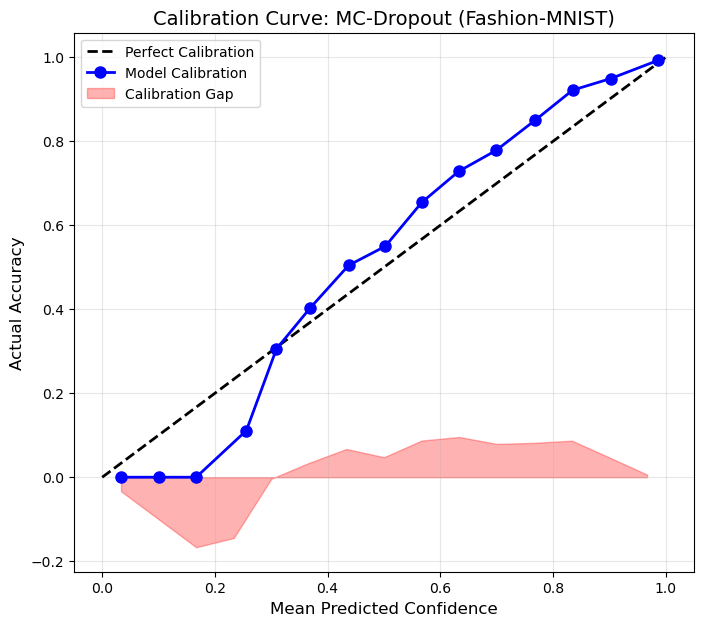


Calibration summary - Samples per bin: [np.int64(0), np.int64(0), np.int64(0), np.int64(9), np.int64(72), np.int64(196), np.int64(329), np.int64(542), np.int64(561), np.int64(515), np.int64(496), np.int64(558), np.int64(663), np.int64(887), np.int64(5172)]
Calibration curve saved to figures/deep_ensemble_calibration.png


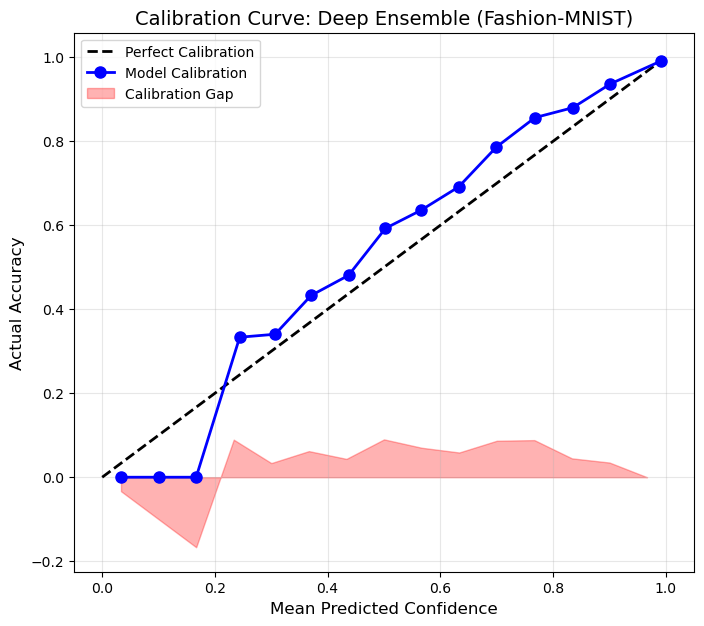


Calibration summary - Samples per bin: [np.int64(0), np.int64(0), np.int64(0), np.int64(15), np.int64(47), np.int64(171), np.int64(285), np.int64(545), np.int64(521), np.int64(476), np.int64(468), np.int64(494), np.int64(574), np.int64(788), np.int64(5616)]
Plotting Confidence Histograms
Confidence histogram saved to figures/mc_dropout_histogram.png


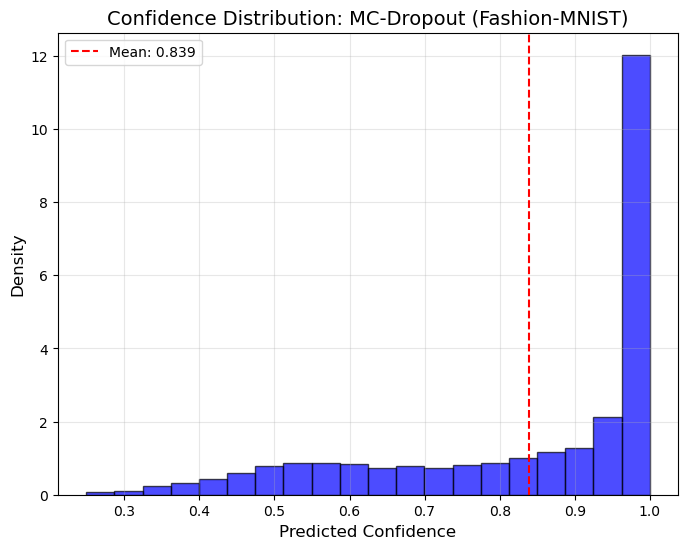

Confidence statistics - Mean: 0.8387, Std: 0.1941
Confidence histogram saved to figures/deep_ensemble_histogram.png


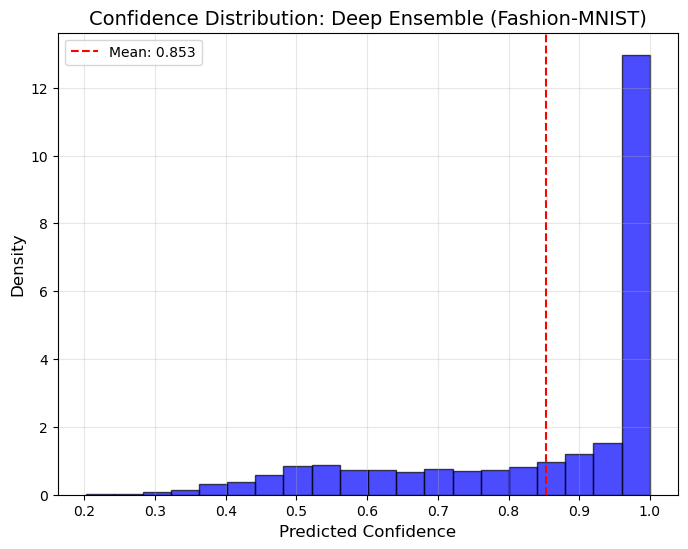

Confidence statistics - Mean: 0.8535, Std: 0.1918


In [22]:
# Task 1d - Plot Calibration Curves and Confidence Histograms

def plot_calibration_curve_task1d(probabilities, labels, title, save_name):
   
    # Get predicted class and confidence
    confidences = np.max(probabilities, axis=1)
    predicted = np.argmax(probabilities, axis=1)
    
    n_bins = 15
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_boundaries[:-1] + bin_boundaries[1:]) / 2
    
    accuracies = []
    mean_confidences = []
    bin_counts = []
    
    for i in range(n_bins):
        in_bin = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i + 1])
        bin_counts.append(np.sum(in_bin))
        
        if np.sum(in_bin) > 0:
            accuracies.append(np.mean(predicted[in_bin] == labels[in_bin]))
            mean_confidences.append(np.mean(confidences[in_bin]))
        else:
            accuracies.append(0)
            mean_confidences.append(bin_centers[i])
    
    # Create plot
    plt.figure(figsize=(8, 7))
    
    # Perfect calibration line
    plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2)
    
    # Calibration curve
    plt.plot(mean_confidences, accuracies, 'bo-', label='Model Calibration', markersize=8, linewidth=2)
    
    # Fill between (gap between confidence and accuracy)
    plt.fill_between(bin_centers, 
                     np.array(accuracies) - np.array(mean_confidences), 
                     0, 
                     alpha=0.3, color='red', label='Calibration Gap')
    
    plt.xlabel('Mean Predicted Confidence', fontsize=12)
    plt.ylabel('Actual Accuracy', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Save figure
    os.makedirs('figures', exist_ok=True)
    plt.savefig(f'figures/{save_name}_calibration.png', dpi=150, bbox_inches='tight')
    print(f"Calibration curve saved to figures/{save_name}_calibration.png")
    plt.show()
    
    # Print bin information
    print(f"\nCalibration summary - Samples per bin: {bin_counts}")

def plot_confidence_histogram(probabilities, title, save_name):
    """
    Plot histogram of predicted confidences.
    Shows distribution of how confident the model is.
    """
    confidences = np.max(probabilities, axis=1)
    
    plt.figure(figsize=(8, 6))
    plt.hist(confidences, bins=20, alpha=0.7, color='blue', edgecolor='black', density=True)
    plt.xlabel('Predicted Confidence', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.title(title, fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # Add statistics
    plt.axvline(np.mean(confidences), color='red', linestyle='--', label=f'Mean: {np.mean(confidences):.3f}')
    plt.legend()
    
    # Save figure
    plt.savefig(f'figures/{save_name}_histogram.png', dpi=150, bbox_inches='tight')
    print(f"Confidence histogram saved to figures/{save_name}_histogram.png")
    plt.show()
    
    print(f"Confidence statistics - Mean: {np.mean(confidences):.4f}, Std: {np.std(confidences):.4f}")

# Convert to numpy for plotting
mc_probs_np = mc_probs.cpu().numpy()
mc_labels_np = mc_labels.cpu().numpy()
ensemble_probs_np = ensemble_probs.cpu().numpy()
ensemble_labels_np = ensemble_labels.cpu().numpy()

# Plot calibration curves

print("Plotting Calibration Curves")

plot_calibration_curve_task1d(
    mc_probs_np, mc_labels_np,
    "Calibration Curve: MC-Dropout (Fashion-MNIST)",
    "mc_dropout"
)
plot_calibration_curve_task1d(
    ensemble_probs_np, ensemble_labels_np,
    "Calibration Curve: Deep Ensemble (Fashion-MNIST)",
    "deep_ensemble"
)

# Plot confidence histograms

print("Plotting Confidence Histograms")

plot_confidence_histogram(
    mc_probs_np,
    "Confidence Distribution: MC-Dropout (Fashion-MNIST)",
    "mc_dropout"
)

plot_confidence_histogram(
    ensemble_probs_np,
    "Confidence Distribution: Deep Ensemble (Fashion-MNIST)",
    "deep_ensemble"
)

In [23]:
# Task 1d - Compute Training Metrics and Final Summary Table

def compute_training_metrics_classifier(model, train_loader, model_name, is_ensemble=False, ensemble_models=None):
    """
    Compute accuracy and NLL on training set.
    """
    print(f"\nComputing {model_name} training set metrics...")
    
    if is_ensemble:
        all_probs = []
        all_labels = []
        
        with torch.no_grad():
            for images, labels in train_loader:
                mean_probs, _ = ensemble_predict_classifier(ensemble_models, images)
                all_probs.append(mean_probs)
                all_labels.append(labels)
    else:
        model.train()
        all_probs = []
        all_labels = []
        
        with torch.no_grad():
            for images, labels in train_loader:
                mean_probs, _ = mc_dropout_predict_classifier(model, images, num_passes=50)
                all_probs.append(mean_probs)
                all_labels.append(labels)
    
    all_probs = torch.cat(all_probs, dim=0).cpu().numpy()
    all_labels = torch.cat(all_labels, dim=0).cpu().numpy()
    
    predicted = np.argmax(all_probs, axis=1)
    accuracy = np.mean(predicted == all_labels)
    
    correct_class_probs = all_probs[np.arange(len(all_labels)), all_labels]
    nll = -np.mean(np.log(correct_class_probs + 1e-8))
    
    print(f"  Training Accuracy: {accuracy*100:.2f}%")
    print(f"  Training NLL: {nll:.4f}")
    
    return accuracy, nll

# Compute training metrics
mc_train_acc, mc_train_nll = compute_training_metrics_classifier(
    mc_classifier, train_loader, "MC-Dropout", is_ensemble=False
)

ensemble_train_acc, ensemble_train_nll = compute_training_metrics_classifier(
    None, train_loader, "Deep Ensemble", is_ensemble=True, ensemble_models=ensemble_classifiers
)

# Final summary table for Task 1d

print("FASHION-MNIST DATASET RESULTS")

print("\n--- TEST SET RESULTS ---")
print(f"{'Model':<20} {'Accuracy':<15} {'NLL':<12} {'ECE':<12}")
print("-" * 59)
# FIXED: Removed *100 and % for ECE - now shows decimal
print(f"{'MC-Dropout':<20} {mc_acc*100:<15.2f}% {mc_nll:<12.4f} {mc_ece:<12.4f}")
print(f"{'Deep Ensemble (k=5)':<20} {ensemble_acc*100:<15.2f}% {ensemble_nll:<12.4f} {ensemble_ece:<12.4f}")

print("\n--- TRAINING SET RESULTS ---")
print(f"{'Model':<20} {'Accuracy':<15} {'NLL':<12}")
print("-" * 47)
print(f"{'MC-Dropout':<20} {mc_train_acc*100:<15.2f}% {mc_train_nll:<12.4f}")
print(f"{'Deep Ensemble (k=5)':<20} {ensemble_train_acc*100:<15.2f}% {ensemble_train_nll:<12.4f}")




Computing MC-Dropout training set metrics...
  Training Accuracy: 89.43%
  Training NLL: 0.3021

Computing Deep Ensemble training set metrics...
  Training Accuracy: 89.97%
  Training NLL: 0.2794
FASHION-MNIST DATASET RESULTS

--- TEST SET RESULTS ---
Model                Accuracy        NLL          ECE         
-----------------------------------------------------------
MC-Dropout           87.55          % 0.3520       0.0371      
Deep Ensemble (k=5)  88.12          % 0.3366       0.0277      

--- TRAINING SET RESULTS ---
Model                Accuracy        NLL         
-----------------------------------------------
MC-Dropout           89.43          % 0.3021      
Deep Ensemble (k=5)  89.97          % 0.2794      


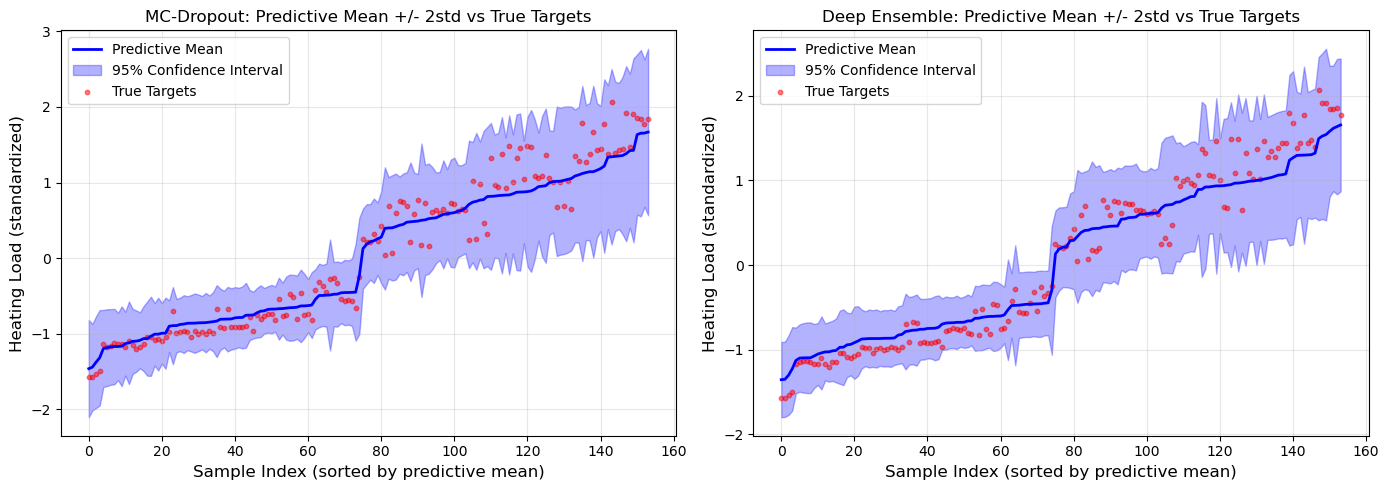

TASK 2a: REGRESSION UNCERTAINTY ANALYSIS - UCI DATASET

--- WHERE IS UNCERTAINTY HIGH? ---
High uncertainty region (top 20%): 31 samples
  Prediction range in this region: [0.50, 1.67]
  Average uncertainty (2*std): 1.0367
  Average absolute error: 0.3422


--- WHERE IS UNCERTAINTY LOW? ---
Low uncertainty region (bottom 20%): 31 samples
  Prediction range in this region: [-1.09, -0.46]
  Average uncertainty (2*std): 0.3618
  Average absolute error: 0.1082


--- COMPARISON BETWEEN MODELS ---
MC-Dropout - Mean uncertainty: 0.6434
Deep Ensemble - Mean uncertainty: 0.5626
MC-Dropout - Mean absolute error: 0.1780
Deep Ensemble - Mean absolute error: 0.1801

--- CORRELATION BETWEEN UNCERTAINTY AND ERROR ---
MC-Dropout: Correlation between uncertainty and error = 0.6376
Deep Ensemble: Correlation between uncertainty and error = 0.7204



In [24]:
#  Task 2a - Visualize Regression Uncertainty for UCI Dataset
# Plot predicted mean +/- std vs true targets
# Discuss where uncertainty is high/low

# Get predictions from MC-Dropout (from Task 1c)
mc_means_np = mc_pred_means.squeeze().cpu().numpy()
mc_stds_np = torch.sqrt(mc_pred_vars).squeeze().cpu().numpy()
mc_targets_np = mc_targets.squeeze().cpu().numpy()

# Get predictions from Deep Ensemble (from Task 1c)
ensemble_means_np = ensemble_pred_means.squeeze().cpu().numpy()
ensemble_stds_np = torch.sqrt(ensemble_pred_vars).squeeze().cpu().numpy()
ensemble_targets_np = ensemble_targets.squeeze().cpu().numpy()

# Sort by predictive mean as required by assignment
sort_idx_mc = np.argsort(mc_means_np)
sorted_mc_means = mc_means_np[sort_idx_mc]
sorted_mc_stds = mc_stds_np[sort_idx_mc]
sorted_mc_targets = mc_targets_np[sort_idx_mc]

sort_idx_ens = np.argsort(ensemble_means_np)
sorted_ens_means = ensemble_means_np[sort_idx_ens]
sorted_ens_stds = ensemble_stds_np[sort_idx_ens]
sorted_ens_targets = ensemble_targets_np[sort_idx_ens]

# X-axis is index after sorting
x_axis_mc = np.arange(len(sorted_mc_means))
x_axis_ens = np.arange(len(sorted_ens_means))

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: MC-Dropout results
axes[0].plot(x_axis_mc, sorted_mc_means, 'b-', label='Predictive Mean', linewidth=2)
axes[0].fill_between(x_axis_mc, 
                     sorted_mc_means - 2*sorted_mc_stds, 
                     sorted_mc_means + 2*sorted_mc_stds, 
                     alpha=0.3, color='blue', label='95% Confidence Interval')
axes[0].scatter(x_axis_mc, sorted_mc_targets, c='red', s=10, alpha=0.5, label='True Targets')
axes[0].set_xlabel('Sample Index (sorted by predictive mean)', fontsize=12)
axes[0].set_ylabel('Heating Load (standardized)', fontsize=12)
axes[0].set_title('MC-Dropout: Predictive Mean +/- 2std vs True Targets', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Deep Ensemble results
axes[1].plot(x_axis_ens, sorted_ens_means, 'b-', label='Predictive Mean', linewidth=2)
axes[1].fill_between(x_axis_ens, 
                     sorted_ens_means - 2*sorted_ens_stds, 
                     sorted_ens_means + 2*sorted_ens_stds, 
                     alpha=0.3, color='blue', label='95% Confidence Interval')
axes[1].scatter(x_axis_ens, sorted_ens_targets, c='red', s=10, alpha=0.5, label='True Targets')
axes[1].set_xlabel('Sample Index (sorted by predictive mean)', fontsize=12)
axes[1].set_ylabel('Heating Load (standardized)', fontsize=12)
axes[1].set_title('Deep Ensemble: Predictive Mean +/- 2std vs True Targets', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/task2a_regression_uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate errors and uncertainties for discussion
mc_errors = np.abs(sorted_mc_means - sorted_mc_targets)
ensemble_errors = np.abs(sorted_ens_means - sorted_ens_targets)
mc_uncertainty = 2 * sorted_mc_stds
ensemble_uncertainty = 2 * sorted_ens_stds

# Identify high and low uncertainty regions
high_unc_threshold = np.percentile(mc_uncertainty, 80)
low_unc_threshold = np.percentile(mc_uncertainty, 20)

high_unc_idx = np.where(mc_uncertainty > high_unc_threshold)[0]
low_unc_idx = np.where(mc_uncertainty < low_unc_threshold)[0]


print("TASK 2a: REGRESSION UNCERTAINTY ANALYSIS - UCI DATASET")


print("\n--- WHERE IS UNCERTAINTY HIGH? ---")
print(f"High uncertainty region (top 20%): {len(high_unc_idx)} samples")
print(f"  Prediction range in this region: [{sorted_mc_means[high_unc_idx].min():.2f}, {sorted_mc_means[high_unc_idx].max():.2f}]")
print(f"  Average uncertainty (2*std): {np.mean(mc_uncertainty[high_unc_idx]):.4f}")
print(f"  Average absolute error: {np.mean(mc_errors[high_unc_idx]):.4f}")
print("")


print("\n--- WHERE IS UNCERTAINTY LOW? ---")
print(f"Low uncertainty region (bottom 20%): {len(low_unc_idx)} samples")
print(f"  Prediction range in this region: [{sorted_mc_means[low_unc_idx].min():.2f}, {sorted_mc_means[low_unc_idx].max():.2f}]")
print(f"  Average uncertainty (2*std): {np.mean(mc_uncertainty[low_unc_idx]):.4f}")
print(f"  Average absolute error: {np.mean(mc_errors[low_unc_idx]):.4f}")
print("")

print("\n--- COMPARISON BETWEEN MODELS ---")
print(f"MC-Dropout - Mean uncertainty: {np.mean(mc_uncertainty):.4f}")
print(f"Deep Ensemble - Mean uncertainty: {np.mean(ensemble_uncertainty):.4f}")
print(f"MC-Dropout - Mean absolute error: {np.mean(mc_errors):.4f}")
print(f"Deep Ensemble - Mean absolute error: {np.mean(ensemble_errors):.4f}")

print("\n--- CORRELATION BETWEEN UNCERTAINTY AND ERROR ---")
from scipy.stats import pearsonr
corr_mc, _ = pearsonr(mc_uncertainty, mc_errors)
corr_ens, _ = pearsonr(ensemble_uncertainty, ensemble_errors)
print(f"MC-Dropout: Correlation between uncertainty and error = {corr_mc:.4f}")
print(f"Deep Ensemble: Correlation between uncertainty and error = {corr_ens:.4f}")
print("")


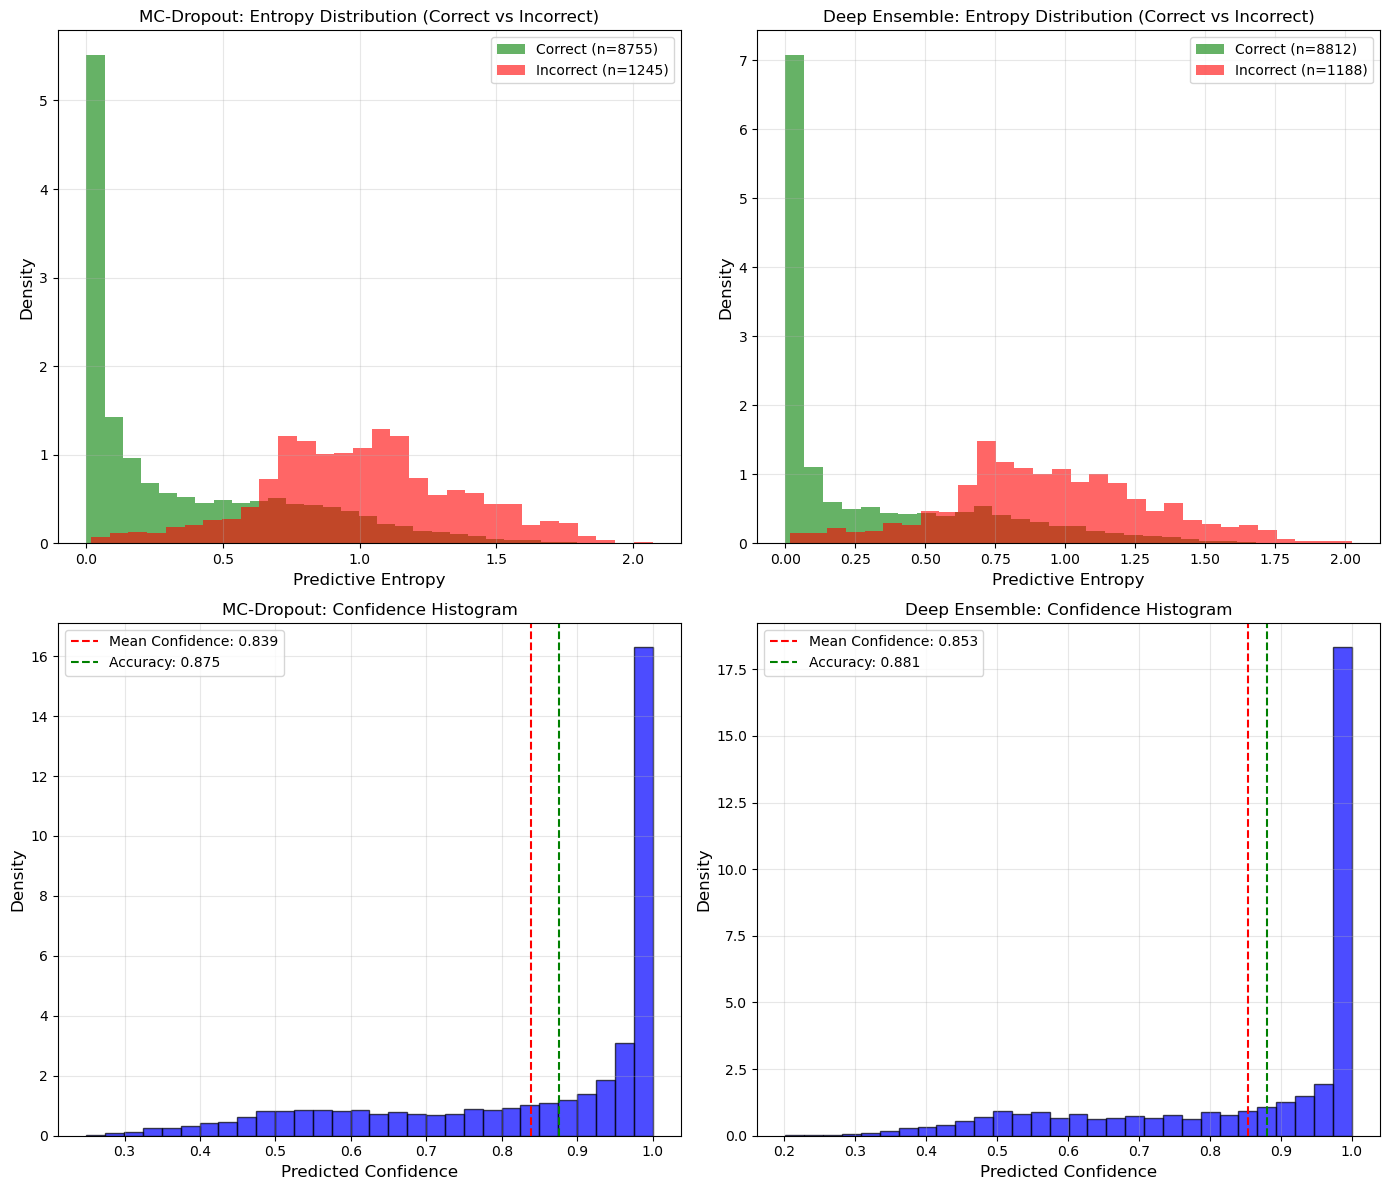

TASK 2b: CLASSIFICATION UNCERTAINTY ANALYSIS - FASHION-MNIST

--- MC-DROPOUT RESULTS ---
Total test samples: 10000
Correct predictions: 8755 (87.55%)
Incorrect predictions: 1245 (12.45%)

Mean entropy (correct): 0.3543
Mean entropy (incorrect): 1.0059
Mean confidence: 0.8387
Overall accuracy: 0.8755
Calibration gap: 0.0368
Overall mean entropy: 0.4355

--- DEEP ENSEMBLE RESULTS ---
Total test samples: 10000
Correct predictions: 8812 (88.12%)
Incorrect predictions: 1188 (11.88%)

Mean entropy (correct): 0.2998
Mean entropy (incorrect): 0.9387
Mean confidence: 0.8535
Overall accuracy: 0.8812
Calibration gap: 0.0277
Overall mean entropy: 0.3757

--- STATISTICAL ANALYSIS ---
MC-Dropout: p-value (correct entropy < incorrect entropy) = 0.000000e+00
Deep Ensemble: p-value (correct entropy < incorrect entropy) = 0.000000e+00
MC-Dropout: Incorrect predictions have SIGNIFICANTLY higher entropy
Deep Ensemble: Incorrect predictions have SIGNIFICANTLY higher entropy


In [25]:
# Task 2b - Visualize Classification Uncertainty for Fashion-MNIST
# Plot predictive entropy histograms for correct vs incorrect predictions
# Display confidence histograms and calibration curves

def compute_predictive_entropy(probabilities):
    """
    Compute predictive entropy from class probabilities.
    Entropy = -sum(p * log(p))
    Higher entropy = more uncertainty about the prediction
    """
    probs = probabilities + 1e-8  # Add small value to avoid log(0)
    entropy = -np.sum(probs * np.log(probs), axis=1)
    return entropy

# Get probabilities from Task 1d (MC-Dropout and Deep Ensemble)
mc_probs_np = mc_probs.cpu().numpy()
mc_labels_np = mc_labels.cpu().numpy()
ensemble_probs_np = ensemble_probs.cpu().numpy()
ensemble_labels_np = ensemble_labels.cpu().numpy()

# Compute predictions and entropies for MC-Dropout
mc_predicted = np.argmax(mc_probs_np, axis=1)
mc_correct_mask = (mc_predicted == mc_labels_np)
mc_incorrect_mask = ~mc_correct_mask
mc_entropies = compute_predictive_entropy(mc_probs_np)
mc_confidences = np.max(mc_probs_np, axis=1)
mc_overall_entropy = np.mean(mc_entropies)


# Compute predictions and entropies for Deep Ensemble
ensemble_predicted = np.argmax(ensemble_probs_np, axis=1)
ensemble_correct_mask = (ensemble_predicted == ensemble_labels_np)
ensemble_incorrect_mask = ~ensemble_correct_mask
ensemble_entropies = compute_predictive_entropy(ensemble_probs_np)
ensemble_confidences = np.max(ensemble_probs_np, axis=1)
ensemble_overall_entropy = np.mean(ensemble_entropies)

# Create figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1a: Entropy histogram for MC-Dropout (correct vs incorrect)
axes[0, 0].hist(mc_entropies[mc_correct_mask], bins=30, alpha=0.6, color='green', 
                label=f'Correct (n={np.sum(mc_correct_mask)})', density=True)
axes[0, 0].hist(mc_entropies[mc_incorrect_mask], bins=30, alpha=0.6, color='red', 
                label=f'Incorrect (n={np.sum(mc_incorrect_mask)})', density=True)
axes[0, 0].set_xlabel('Predictive Entropy', fontsize=12)
axes[0, 0].set_ylabel('Density', fontsize=12)
axes[0, 0].set_title('MC-Dropout: Entropy Distribution (Correct vs Incorrect)', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 1b: Entropy histogram for Deep Ensemble (correct vs incorrect)
axes[0, 1].hist(ensemble_entropies[ensemble_correct_mask], bins=30, alpha=0.6, color='green', 
                label=f'Correct (n={np.sum(ensemble_correct_mask)})', density=True)
axes[0, 1].hist(ensemble_entropies[ensemble_incorrect_mask], bins=30, alpha=0.6, color='red', 
                label=f'Incorrect (n={np.sum(ensemble_incorrect_mask)})', density=True)
axes[0, 1].set_xlabel('Predictive Entropy', fontsize=12)
axes[0, 1].set_ylabel('Density', fontsize=12)
axes[0, 1].set_title('Deep Ensemble: Entropy Distribution (Correct vs Incorrect)', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 2a: Confidence histogram for MC-Dropout
axes[1, 0].hist(mc_confidences, bins=30, alpha=0.7, color='blue', edgecolor='black', density=True)
axes[1, 0].axvline(np.mean(mc_confidences), color='red', linestyle='--', 
                   label=f'Mean Confidence: {np.mean(mc_confidences):.3f}')
axes[1, 0].axvline(np.mean(mc_predicted == mc_labels_np), color='green', linestyle='--',
                   label=f'Accuracy: {np.mean(mc_predicted == mc_labels_np):.3f}')
axes[1, 0].set_xlabel('Predicted Confidence', fontsize=12)
axes[1, 0].set_ylabel('Density', fontsize=12)
axes[1, 0].set_title('MC-Dropout: Confidence Histogram', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 2b: Confidence histogram for Deep Ensemble
axes[1, 1].hist(ensemble_confidences, bins=30, alpha=0.7, color='blue', edgecolor='black', density=True)
axes[1, 1].axvline(np.mean(ensemble_confidences), color='red', linestyle='--', 
                   label=f'Mean Confidence: {np.mean(ensemble_confidences):.3f}')
axes[1, 1].axvline(np.mean(ensemble_predicted == ensemble_labels_np), color='green', linestyle='--',
                   label=f'Accuracy: {np.mean(ensemble_predicted == ensemble_labels_np):.3f}')
axes[1, 1].set_xlabel('Predicted Confidence', fontsize=12)
axes[1, 1].set_ylabel('Density', fontsize=12)
axes[1, 1].set_title('Deep Ensemble: Confidence Histogram', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/task2b_entropy_and_confidence_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

# Print statistics for MC-Dropout

print("TASK 2b: CLASSIFICATION UNCERTAINTY ANALYSIS - FASHION-MNIST")


print("\n--- MC-DROPOUT RESULTS ---")
print(f"Total test samples: {len(mc_labels_np)}")
print(f"Correct predictions: {np.sum(mc_correct_mask)} ({np.sum(mc_correct_mask)/len(mc_labels_np)*100:.2f}%)")
print(f"Incorrect predictions: {np.sum(mc_incorrect_mask)} ({np.sum(mc_incorrect_mask)/len(mc_labels_np)*100:.2f}%)")
print(f"\nMean entropy (correct): {np.mean(mc_entropies[mc_correct_mask]):.4f}")
print(f"Mean entropy (incorrect): {np.mean(mc_entropies[mc_incorrect_mask]):.4f}")
print(f"Mean confidence: {np.mean(mc_confidences):.4f}")
print(f"Overall accuracy: {np.mean(mc_predicted == mc_labels_np):.4f}")
print(f"Calibration gap: {abs(np.mean(mc_confidences) - np.mean(mc_predicted == mc_labels_np)):.4f}")
print(f"Overall mean entropy: {np.mean(mc_entropies):.4f}")

print("\n--- DEEP ENSEMBLE RESULTS ---")
print(f"Total test samples: {len(ensemble_labels_np)}")
print(f"Correct predictions: {np.sum(ensemble_correct_mask)} ({np.sum(ensemble_correct_mask)/len(ensemble_labels_np)*100:.2f}%)")
print(f"Incorrect predictions: {np.sum(ensemble_incorrect_mask)} ({np.sum(ensemble_incorrect_mask)/len(ensemble_labels_np)*100:.2f}%)")
print(f"\nMean entropy (correct): {np.mean(ensemble_entropies[ensemble_correct_mask]):.4f}")
print(f"Mean entropy (incorrect): {np.mean(ensemble_entropies[ensemble_incorrect_mask]):.4f}")
print(f"Mean confidence: {np.mean(ensemble_confidences):.4f}")
print(f"Overall accuracy: {np.mean(ensemble_predicted == ensemble_labels_np):.4f}")
print(f"Calibration gap: {abs(np.mean(ensemble_confidences) - np.mean(ensemble_predicted == ensemble_labels_np)):.4f}")
print(f"Overall mean entropy: {np.mean(ensemble_entropies):.4f}")

# Statistical test for entropy difference
from scipy.stats import mannwhitneyu

print("\n--- STATISTICAL ANALYSIS ---")
stat_mc, p_mc = mannwhitneyu(mc_entropies[mc_correct_mask], mc_entropies[mc_incorrect_mask], alternative='less')
stat_ens, p_ens = mannwhitneyu(ensemble_entropies[ensemble_correct_mask], ensemble_entropies[ensemble_incorrect_mask], alternative='less')

print(f"MC-Dropout: p-value (correct entropy < incorrect entropy) = {p_mc:.6e}")
print(f"Deep Ensemble: p-value (correct entropy < incorrect entropy) = {p_ens:.6e}")

if p_mc < 0.05:
    print("MC-Dropout: Incorrect predictions have SIGNIFICANTLY higher entropy")
else:
    print("MC-Dropout: No significant difference in entropy")

if p_ens < 0.05:
    print("Deep Ensemble: Incorrect predictions have SIGNIFICANTLY higher entropy")
else:
    print("Deep Ensemble: No significant difference in entropy")

CALIBRATION CURVES (Reliability Diagarams)

MC-Dropout - Calibration Data:
Bin  Confidence   Accuracy     Samples  Type
--------------------------------------------------
3    0.2558       0.1111       9        Overconfident
4    0.3092       0.3056       72       Overconfident
5    0.3690       0.4031       196      Underconfident
6    0.4373       0.5046       329      Underconfident
7    0.5022       0.5498       542      Underconfident
8    0.5669       0.6542       561      Underconfident
9    0.6323       0.7282       515      Underconfident
10   0.6989       0.7782       496      Underconfident
11   0.7676       0.8495       558      Underconfident
12   0.8345       0.9216       663      Underconfident
13   0.9022       0.9493       887      Underconfident
14   0.9864       0.9927       5172     Underconfident


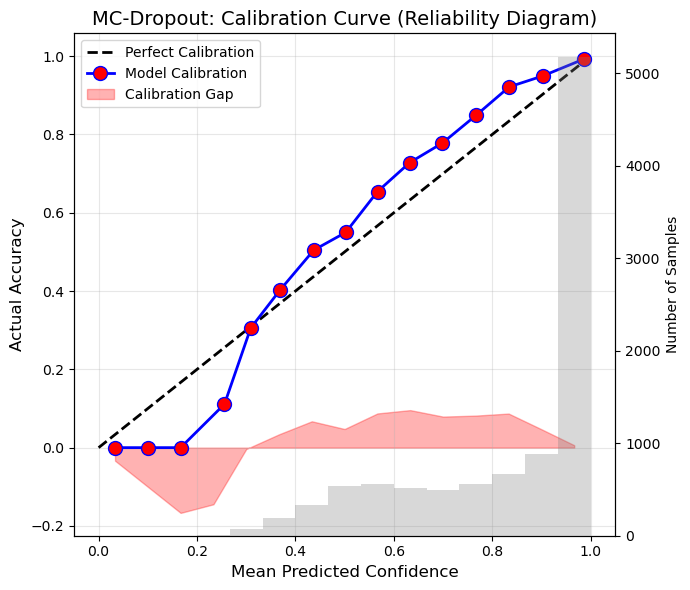


Calibration analysis for MC-Dropout:
  Overconfident bins (confidence > accuracy): 2 bins
  Underconfident bins (confidence < accuracy): 10 bins

Deep_Ensemble - Calibration Data:
Bin  Confidence   Accuracy     Samples  Type
--------------------------------------------------
3    0.2439       0.3333       15       Underconfident
4    0.3068       0.3404       47       Underconfident
5    0.3706       0.4327       171      Underconfident
6    0.4370       0.4807       285      Underconfident
7    0.5026       0.5927       545      Underconfident
8    0.5651       0.6353       521      Underconfident
9    0.6323       0.6912       476      Underconfident
10   0.6995       0.7863       468      Underconfident
11   0.7679       0.8563       494      Underconfident
12   0.8349       0.8798       574      Underconfident
13   0.9016       0.9365       788      Underconfident
14   0.9906       0.9906       5616     Overconfident


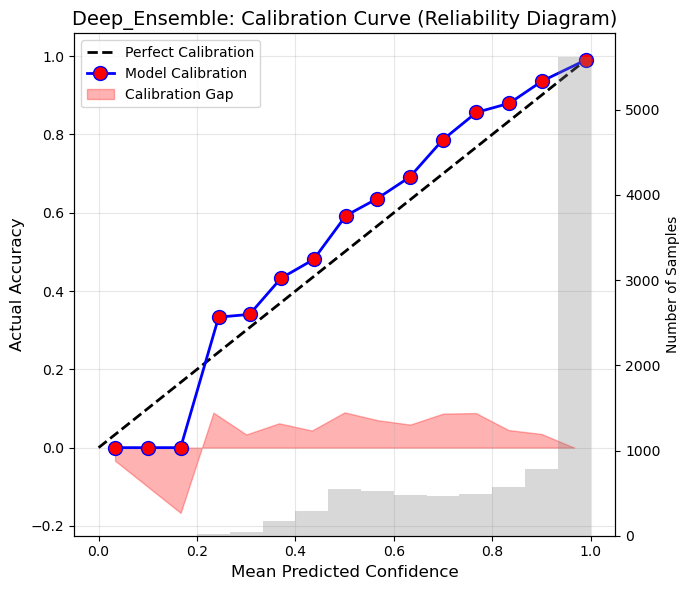


Calibration analysis for Deep_Ensemble:
  Overconfident bins (confidence > accuracy): 1 bins
  Underconfident bins (confidence < accuracy): 11 bins


In [26]:
# Task 2b - Calibration Curves

def plot_calibration_curve_task2b(probabilities, labels, model_name):
 
    """
    Plot calibration curve (reliability diagram).
    Perfect calibration means confidence = accuracy (diagonal line).
    """
    confidences = np.max(probabilities, axis=1)
    predicted = np.argmax(probabilities, axis=1)
    
    n_bins = 15
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_boundaries[:-1] + bin_boundaries[1:]) / 2
    
    accuracies = []
    mean_confidences = []
    bin_counts = []
    
    for i in range(n_bins):
        in_bin = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i + 1])
        bin_counts.append(np.sum(in_bin))
        
        if np.sum(in_bin) > 0:
            accuracies.append(np.mean(predicted[in_bin] == labels[in_bin]))
            mean_confidences.append(np.mean(confidences[in_bin]))
        else:
            accuracies.append(0)
            mean_confidences.append(bin_centers[i])

    # Add this after the bin loop, before creating the plot
    print(f"\n{model_name} - Calibration Data:")
    print(f"{'Bin':<4} {'Confidence':<12} {'Accuracy':<12} {'Samples':<8} {'Type'}")
    print("-" * 50)
    for i in range(n_bins):
     if bin_counts[i] > 0:
        diff = mean_confidences[i] - accuracies[i]
        bin_type = "Overconfident" if diff > 0 else "Underconfident" if diff < 0 else "Perfect"
        print(f"{i:<4} {mean_confidences[i]:<12.4f} {accuracies[i]:<12.4f} {bin_counts[i]:<8} {bin_type}")
    
    # Create figure
    fig, ax = plt.subplots(figsize=(7, 6))
    
    # Perfect calibration line
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2)
    
    # Calibration curve
    #ax.plot(mean_confidences, accuracies, 'bo-', label='Model Calibration', markersize=8, linewidth=2)
    ax.plot(mean_confidences, accuracies, 'bo-', label='Model Calibration', markersize=10, linewidth=2, markerfacecolor='red')
    
    # Fill between (gap between confidence and accuracy)
    ax.fill_between(bin_centers, 
                    np.array(accuracies) - np.array(mean_confidences), 
                    0, 
                    alpha=0.3, color='red', label='Calibration Gap')
    
    # Add bar chart showing sample distribution
    ax2 = ax.twinx()
    ax2.bar(bin_centers, bin_counts, width=1/n_bins, alpha=0.3, color='gray', label='Sample Count')
    ax2.set_ylabel('Number of Samples', fontsize=10)
    
    ax.set_xlabel('Mean Predicted Confidence', fontsize=12)
    ax.set_ylabel('Actual Accuracy', fontsize=12)
    ax.set_title(f'{model_name}: Calibration Curve (Reliability Diagram)', fontsize=14)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'figures/{model_name}_calibration_curve.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Calculate ECE (Expected Calibration Error)
    ece = 0
    n_samples = len(labels)
    for i in range(n_bins):
        if bin_counts[i] > 0:
            ece += (bin_counts[i] / n_samples) * abs(accuracies[i] - mean_confidences[i])
    
  #  print(f"\n{model_name} - Expected Calibration Error (ECE): {ece*100:.2f}%")
  #  print(f"\n{model_name} - Expected Calibration Error (ECE): {ece:.4f}")
    
    # Print calibration analysis
    print(f"\nCalibration analysis for {model_name}:")
    print(f"  Overconfident bins (confidence > accuracy): {sum(1 for i in range(n_bins) if mean_confidences[i] > accuracies[i] and bin_counts[i] > 0)} bins")
    print(f"  Underconfident bins (confidence < accuracy): {sum(1 for i in range(n_bins) if mean_confidences[i] < accuracies[i] and bin_counts[i] > 0)} bins")
    
    return ece

# Plot calibration curves for both models

print("CALIBRATION CURVES (Reliability Diagarams)")


ece_mc = plot_calibration_curve_task2b(mc_probs_np, mc_labels_np, "MC-Dropout")
ece_ensemble = plot_calibration_curve_task2b(ensemble_probs_np, ensemble_labels_np, "Deep_Ensemble")

Task 2c: Epistemic VS Aleatoric Uncertainity

Computing uncertainty components for MC-Dropout...

--- UNCERTAINTY COMPONENT STATISTICS ---
Mean Aleatoric uncertainty (std): 0.277693
Mean Epistemic uncertainty (std): 0.160979
Mean Total uncertainty (std): 0.323618

Epistemic proportion of total: 25.22%
Aleatoric proportion of total: 74.78%
Sum: 100.00%


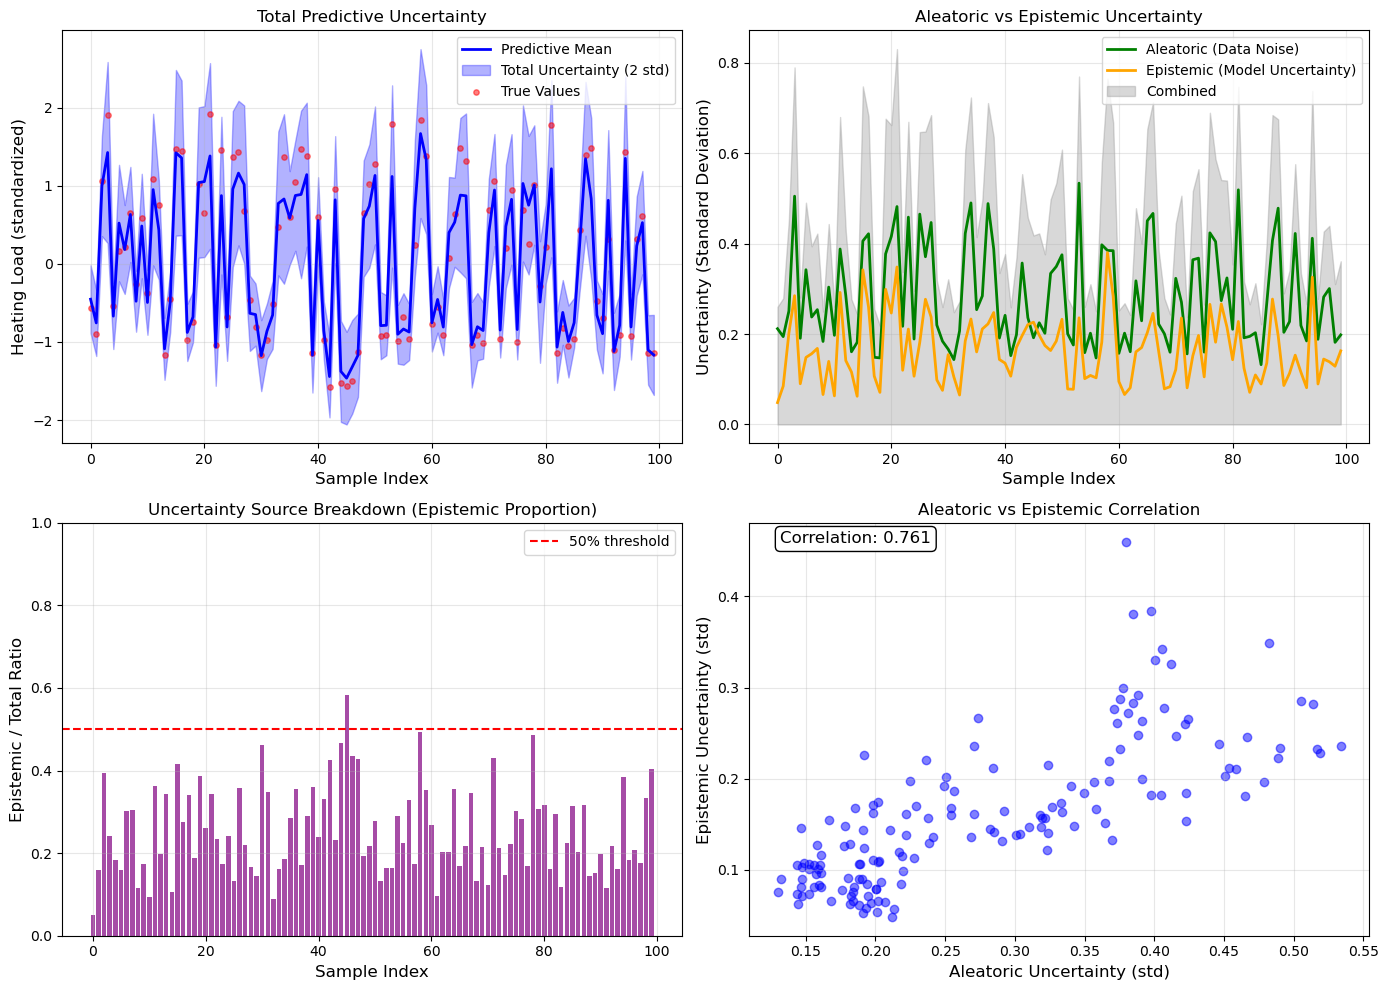

Task 2c: Uncertainty components computed and plotted
Computing Uncertainity Components for deep Ensemble (UCI)

--- DEEP ENSEMBLE UNCERTAINTY COMPONENT STATISTICS ---
Mean Aleatoric uncertainty (std): 0.272662
Mean Epistemic uncertainty (std): 0.066117
Mean Total uncertainty (std): 0.281319

Epistemic proportion: 6.66%
Aleatoric proportion: 93.34%
Sum: 100.00%


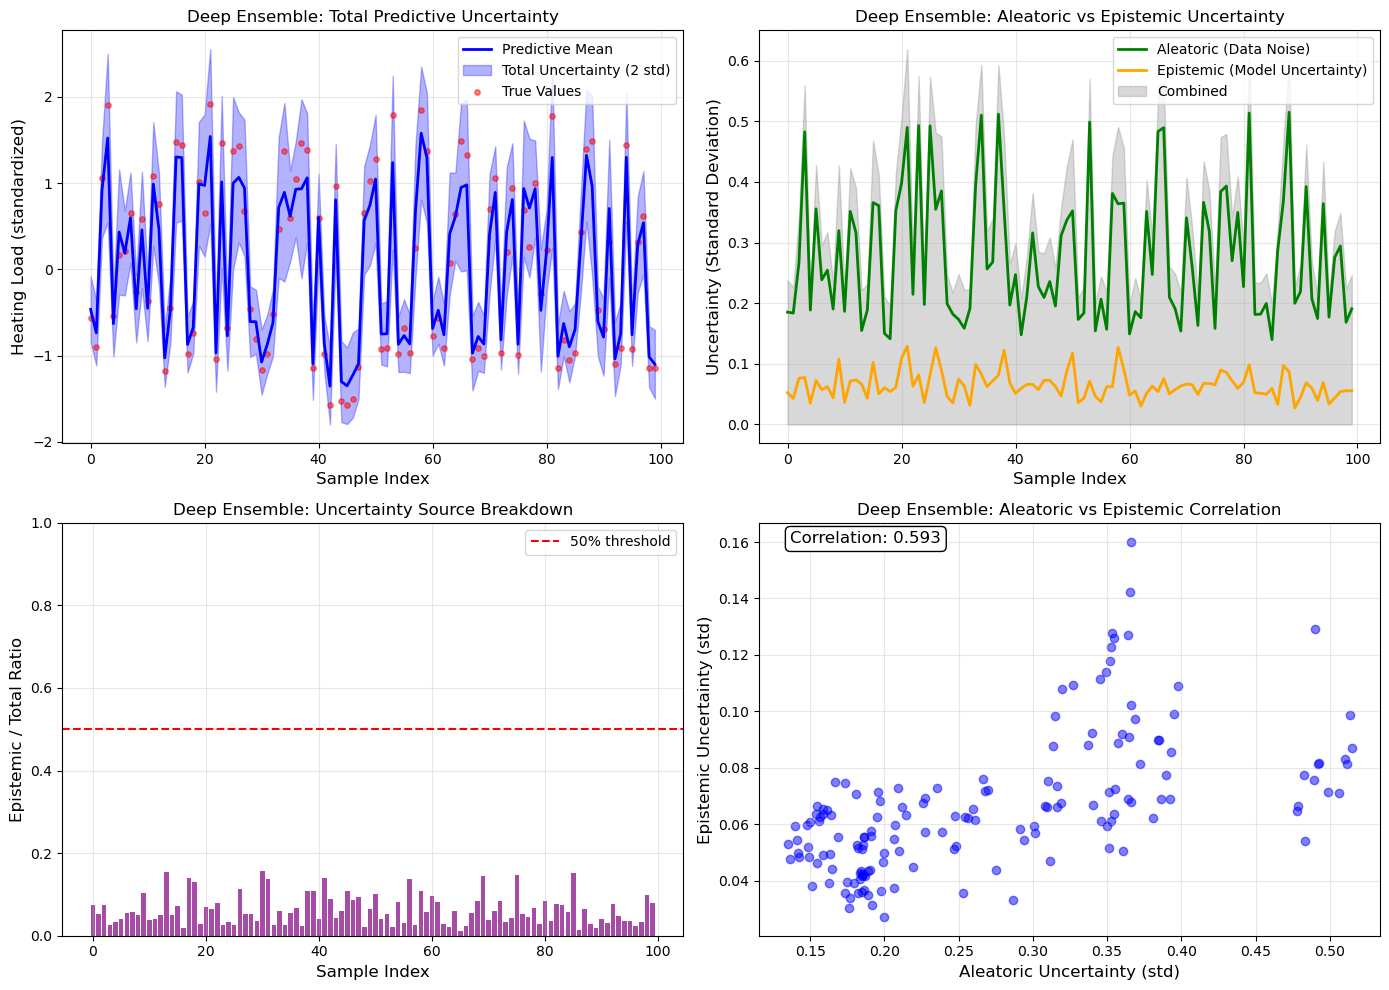

In [27]:
# Task 2c - Separate Epistemic and Aleatoric Uncertainty for UCI Dataset

def separate_uncertainties(model, x, num_passes=50):
    """
    Separate total uncertainty into epistemic and aleatoric components.
    
    Total uncertainty = aleatoric + epistemic
    
    Aleatoric uncertainty: average of predicted variances (data noise)
    Epistemic uncertainty: variance of predicted means (model uncertainty)
    """
    model.train()  # Keep dropout active for MC sampling
    
    all_means = []
    all_variances = []
    
    with torch.no_grad():
        for _ in range(num_passes):
            mean, var = model(x)
            all_means.append(mean)
            all_variances.append(var)
    
    # Stack results from all passes
    all_means = torch.stack(all_means)
    all_variances = torch.stack(all_variances)
    
    # Epistemic uncertainty: variance of means across passes
    # High when model is uncertain due to limited training data
    epistemic = all_means.var(dim=0)
    
    # Aleatoric uncertainty: average of predicted variances across passes
    # High when the data itself is noisy or ambiguous
    aleatoric = all_variances.mean(dim=0)
    
    # Total uncertainty = aleatoric + epistemic
    total = aleatoric + epistemic
    
    return total, aleatoric, epistemic

# Compute uncertainty components for MC-Dropout on UCI test set

print("Task 2c: Epistemic VS Aleatoric Uncertainity")


print("\nComputing uncertainty components for MC-Dropout...")
total_uncertainty, aleatoric_uncertainty, epistemic_uncertainty = separate_uncertainties(
    mc_regressor, X_test_tensor, num_passes=50
)

# Convert to standard deviation for easier interpretation
total_std = torch.sqrt(total_uncertainty).squeeze().cpu().numpy()
aleatoric_std = torch.sqrt(aleatoric_uncertainty).squeeze().cpu().numpy()
epistemic_std = torch.sqrt(epistemic_uncertainty).squeeze().cpu().numpy()
pred_means_np = mc_pred_means.squeeze().cpu().numpy()
targets_np = mc_targets.squeeze().cpu().numpy()

# Calculate variances for proportion (correct way)
aleatoric_var = aleatoric_std ** 2
epistemic_var = epistemic_std ** 2
total_var = total_std ** 2

epistemic_prop = np.mean(epistemic_var / (total_var + 1e-8))
aleatoric_prop = np.mean(aleatoric_var / (total_var + 1e-8))

# Print component statistics
print("\n--- UNCERTAINTY COMPONENT STATISTICS ---")
print(f"Mean Aleatoric uncertainty (std): {np.mean(aleatoric_std):.6f}")
print(f"Mean Epistemic uncertainty (std): {np.mean(epistemic_std):.6f}")
print(f"Mean Total uncertainty (std): {np.mean(total_std):.6f}")
print(f"\nEpistemic proportion of total: {epistemic_prop:.2%}")
print(f"Aleatoric proportion of total: {aleatoric_prop:.2%}")
print(f"Sum: {aleatoric_prop + epistemic_prop:.2%}")

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Take first 100 samples for clearer visualization
n_show = 100
x_axis = np.arange(n_show)

# Plot 1: Total uncertainty with predictions
axes[0, 0].plot(x_axis, pred_means_np[:n_show], 'b-', label='Predictive Mean', linewidth=2)
axes[0, 0].fill_between(x_axis, 
                        pred_means_np[:n_show] - 2*total_std[:n_show], 
                        pred_means_np[:n_show] + 2*total_std[:n_show], 
                        alpha=0.3, color='blue', label='Total Uncertainty (2 std)')
axes[0, 0].scatter(x_axis, targets_np[:n_show], c='red', s=15, alpha=0.5, label='True Values')
axes[0, 0].set_xlabel('Sample Index', fontsize=12)
axes[0, 0].set_ylabel('Heating Load (standardized)', fontsize=12)
axes[0, 0].set_title('Total Predictive Uncertainty', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Aleatoric vs Epistemic uncertainty comparison
axes[0, 1].plot(x_axis, aleatoric_std[:n_show], 'g-', label='Aleatoric (Data Noise)', linewidth=2)
axes[0, 1].plot(x_axis, epistemic_std[:n_show], 'orange', label='Epistemic (Model Uncertainty)', linewidth=2)
axes[0, 1].fill_between(x_axis, 0, aleatoric_std[:n_show] + epistemic_std[:n_show], 
                        alpha=0.3, color='gray', label='Combined')
axes[0, 1].set_xlabel('Sample Index', fontsize=12)
axes[0, 1].set_ylabel('Uncertainty (Standard Deviation)', fontsize=12)
axes[0, 1].set_title('Aleatoric vs Epistemic Uncertainty', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Ratio of epistemic to total uncertainty (using variances)
ratio = epistemic_var / (total_var + 1e-8)
axes[1, 0].bar(x_axis, ratio[:n_show], color='purple', alpha=0.7)
axes[1, 0].axhline(y=0.5, color='r', linestyle='--', label='50% threshold')
axes[1, 0].set_xlabel('Sample Index', fontsize=12)
axes[1, 0].set_ylabel('Epistemic / Total Ratio', fontsize=12)
axes[1, 0].set_title('Uncertainty Source Breakdown (Epistemic Proportion)', fontsize=12)
axes[1, 0].set_ylim([0, 1])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Scatter plot of aleatoric vs epistemic
axes[1, 1].scatter(aleatoric_std, epistemic_std, c='blue', alpha=0.5)
axes[1, 1].set_xlabel('Aleatoric Uncertainty (std)', fontsize=12)
axes[1, 1].set_ylabel('Epistemic Uncertainty (std)', fontsize=12)
axes[1, 1].set_title('Aleatoric vs Epistemic Correlation', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

# Add correlation annotation
from scipy.stats import pearsonr
corr, _ = pearsonr(aleatoric_std, epistemic_std)
axes[1, 1].annotate(f'Correlation: {corr:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', 
                    fontsize=12, bbox=dict(boxstyle='round', facecolor='white'))

plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/task2c_uncertainty_components.png', dpi=150, bbox_inches='tight')
plt.show()


print("Task 2c: Uncertainty components computed and plotted")


# Deep Ensemble Uncertainity Components (UCI Dataset)


print("Computing Uncertainity Components for deep Ensemble (UCI)")


def separate_uncertainties_ensemble(ensemble_models, x):
    """
    Separate total uncertainty for Deep Ensemble.
    """
    all_means = []
    all_variances = []
    
    with torch.no_grad():
        for model in ensemble_models:
            model.eval()
            mean, var = model(x)
            all_means.append(mean)
            all_variances.append(var)
    
    all_means = torch.stack(all_means)
    all_variances = torch.stack(all_variances)
    
    epistemic = all_means.var(dim=0)
    aleatoric = all_variances.mean(dim=0)
    total = aleatoric + epistemic
    
    return total, aleatoric, epistemic

# Compute for Deep Ensemble
total_ens, aleatoric_ens, epistemic_ens = separate_uncertainties_ensemble(
    ensemble_regressors, X_test_tensor
)

# Convert to standard deviation
total_std_ens = torch.sqrt(total_ens).squeeze().cpu().numpy()
aleatoric_std_ens = torch.sqrt(aleatoric_ens).squeeze().cpu().numpy()
epistemic_std_ens = torch.sqrt(epistemic_ens).squeeze().cpu().numpy()

# Get predictions for Deep Ensemble (already have from Cell 15)
ens_pred_means = ensemble_pred_means.squeeze().cpu().numpy()
ens_targets = ensemble_targets.squeeze().cpu().numpy()

# Calculate proportions
aleatoric_var_ens = aleatoric_std_ens ** 2
epistemic_var_ens = epistemic_std_ens ** 2
total_var_ens = total_std_ens ** 2

epistemic_prop_ens = np.mean(epistemic_var_ens / (total_var_ens + 1e-8))
aleatoric_prop_ens = np.mean(aleatoric_var_ens / (total_var_ens + 1e-8))

print("\n--- DEEP ENSEMBLE UNCERTAINTY COMPONENT STATISTICS ---")
print(f"Mean Aleatoric uncertainty (std): {np.mean(aleatoric_std_ens):.6f}")
print(f"Mean Epistemic uncertainty (std): {np.mean(epistemic_std_ens):.6f}")
print(f"Mean Total uncertainty (std): {np.mean(total_std_ens):.6f}")
print(f"\nEpistemic proportion: {epistemic_prop_ens:.2%}")
print(f"Aleatoric proportion: {aleatoric_prop_ens:.2%}")
print(f"Sum: {aleatoric_prop_ens + epistemic_prop_ens:.2%}")

# Create plots for Deep Ensemble
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

n_show = 100
x_axis = np.arange(n_show)

# Plot 1: Total uncertainty
axes[0, 0].plot(x_axis, ens_pred_means[:n_show], 'b-', label='Predictive Mean', linewidth=2)
axes[0, 0].fill_between(x_axis, 
                        ens_pred_means[:n_show] - 2*total_std_ens[:n_show], 
                        ens_pred_means[:n_show] + 2*total_std_ens[:n_show], 
                        alpha=0.3, color='blue', label='Total Uncertainty (2 std)')
axes[0, 0].scatter(x_axis, ens_targets[:n_show], c='red', s=15, alpha=0.5, label='True Values')
axes[0, 0].set_xlabel('Sample Index', fontsize=12)
axes[0, 0].set_ylabel('Heating Load (standardized)', fontsize=12)
axes[0, 0].set_title('Deep Ensemble: Total Predictive Uncertainty', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Aleatoric vs Epistemic
axes[0, 1].plot(x_axis, aleatoric_std_ens[:n_show], 'g-', label='Aleatoric (Data Noise)', linewidth=2)
axes[0, 1].plot(x_axis, epistemic_std_ens[:n_show], 'orange', label='Epistemic (Model Uncertainty)', linewidth=2)
axes[0, 1].fill_between(x_axis, 0, aleatoric_std_ens[:n_show] + epistemic_std_ens[:n_show], 
                        alpha=0.3, color='gray', label='Combined')
axes[0, 1].set_xlabel('Sample Index', fontsize=12)
axes[0, 1].set_ylabel('Uncertainty (Standard Deviation)', fontsize=12)
axes[0, 1].set_title('Deep Ensemble: Aleatoric vs Epistemic Uncertainty', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Epistemic ratio
ratio_ens = epistemic_var_ens / (total_var_ens + 1e-8)
axes[1, 0].bar(x_axis, ratio_ens[:n_show], color='purple', alpha=0.7)
axes[1, 0].axhline(y=0.5, color='r', linestyle='--', label='50% threshold')
axes[1, 0].set_xlabel('Sample Index', fontsize=12)
axes[1, 0].set_ylabel('Epistemic / Total Ratio', fontsize=12)
axes[1, 0].set_title('Deep Ensemble: Uncertainty Source Breakdown', fontsize=12)
axes[1, 0].set_ylim([0, 1])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Correlation
axes[1, 1].scatter(aleatoric_std_ens, epistemic_std_ens, c='blue', alpha=0.5)
axes[1, 1].set_xlabel('Aleatoric Uncertainty (std)', fontsize=12)
axes[1, 1].set_ylabel('Epistemic Uncertainty (std)', fontsize=12)
axes[1, 1].set_title('Deep Ensemble: Aleatoric vs Epistemic Correlation', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)
corr_ens, _ = pearsonr(aleatoric_std_ens, epistemic_std_ens)
axes[1, 1].annotate(f'Correlation: {corr_ens:.3f}', xy=(0.05, 0.95), xycoords='axes fraction', 
                    fontsize=12, bbox=dict(boxstyle='round', facecolor='white'))

plt.tight_layout()
plt.savefig('figures/task2c_deep_ensemble_uncertainty_components.png', dpi=150, bbox_inches='tight')
plt.show()



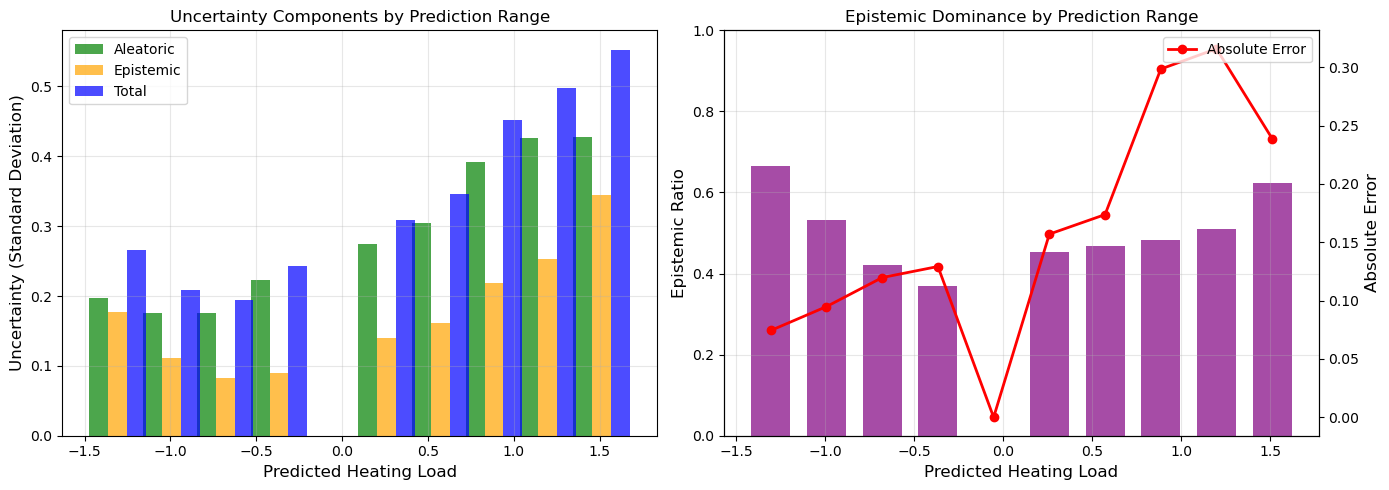


--- UNCERTAINTY ANALYSIS BY PREDICTION RANGE ---
Range [-1.46, -1.15]: Epistemic ratio = 66.62%, Total std = 0.2653, Error = 0.0744
Range [-1.15, -0.84]: Epistemic ratio = 53.14%, Total std = 0.2082, Error = 0.0949
Range [-0.84, -0.52]: Epistemic ratio = 42.10%, Total std = 0.1948, Error = 0.1197
Range [-0.52, -0.21]: Epistemic ratio = 36.96%, Total std = 0.2425, Error = 0.1292
Range [0.10, 0.42]: Epistemic ratio = 45.36%, Total std = 0.3093, Error = 0.1570
Range [0.42, 0.73]: Epistemic ratio = 46.71%, Total std = 0.3456, Error = 0.1737
Range [0.73, 1.04]: Epistemic ratio = 48.35%, Total std = 0.4516, Error = 0.2984
Range [1.04, 1.36]: Epistemic ratio = 50.92%, Total std = 0.4979, Error = 0.3158
Range [1.36, 1.67]: Epistemic ratio = 62.27%, Total std = 0.5527, Error = 0.2388

--- UNCERTAINTY FOR HIGH VS LOW ERROR SAMPLES ---
High error samples (top 20%): n=31
  Mean Aleatoric std: 0.422578
  Mean Epistemic std: 0.206473
  Mean Total std: 0.471464
  Epistemic ratio: 43.55%

Low error s

In [28]:
#  Task 2c - Analyze uncertainty components by prediction range and error (extra)

def analyze_uncertainty_by_prediction_range(pred_means, aleatoric_std, epistemic_std, total_std, targets):
    """
    Analyze which uncertainty type dominates in different prediction ranges.
    """
    # Create bins based on prediction values
    n_bins = 10
    bin_edges = np.linspace(pred_means.min(), pred_means.max(), n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    aleatoric_by_bin = []
    epistemic_by_bin = []
    total_by_bin = []
    error_by_bin = []
    
    for i in range(n_bins):
        in_bin = (pred_means >= bin_edges[i]) & (pred_means < bin_edges[i + 1])
        if np.sum(in_bin) > 0:
            aleatoric_by_bin.append(np.mean(aleatoric_std[in_bin]))
            epistemic_by_bin.append(np.mean(epistemic_std[in_bin]))
            total_by_bin.append(np.mean(total_std[in_bin]))
            error_by_bin.append(np.mean(np.abs(pred_means[in_bin] - targets[in_bin])))
        else:
            aleatoric_by_bin.append(0)
            epistemic_by_bin.append(0)
            total_by_bin.append(0)
            error_by_bin.append(0)
    
    # Create plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Uncertainty components by prediction range
    width = (bin_edges[1] - bin_edges[0]) * 0.7
    x_pos = bin_centers
    
    axes[0].bar(x_pos - width/2, aleatoric_by_bin, width/2, label='Aleatoric', color='green', alpha=0.7)
    axes[0].bar(x_pos, epistemic_by_bin, width/2, label='Epistemic', color='orange', alpha=0.7)
    axes[0].bar(x_pos + width/2, total_by_bin, width/2, label='Total', color='blue', alpha=0.7)
    axes[0].set_xlabel('Predicted Heating Load', fontsize=12)
    axes[0].set_ylabel('Uncertainty (Standard Deviation)', fontsize=12)
    axes[0].set_title('Uncertainty Components by Prediction Range', fontsize=12)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Epistemic ratio and error by prediction range
    ep_ratio = np.array(epistemic_by_bin) / (np.array(total_by_bin) + 1e-8)
    axes[1].bar(x_pos, ep_ratio, width=width, label='Epistemic/Total Ratio', color='purple', alpha=0.7)
    axes[1].set_xlabel('Predicted Heating Load', fontsize=12)
    axes[1].set_ylabel('Epistemic Ratio', fontsize=12)
    axes[1].set_title('Epistemic Dominance by Prediction Range', fontsize=12)
    axes[1].set_ylim([0, 1])
    axes[1].grid(True, alpha=0.3)
    
    # Add second y-axis for error
    ax2 = axes[1].twinx()
    ax2.plot(x_pos, error_by_bin, 'r-o', label='Absolute Error', linewidth=2)
    ax2.set_ylabel('Absolute Error', fontsize=12)
    ax2.legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig('figures/task2c_uncertainty_by_prediction_range.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print analysis
    print("\n--- UNCERTAINTY ANALYSIS BY PREDICTION RANGE ---")
    for i in range(n_bins):
        if total_by_bin[i] > 0:
            ep_ratio_val = epistemic_by_bin[i] / (total_by_bin[i] + 1e-8)
            print(f"Range [{bin_edges[i]:.2f}, {bin_edges[i+1]:.2f}]: "
                  f"Epistemic ratio = {ep_ratio_val:.2%}, "
                  f"Total std = {total_by_bin[i]:.4f}, "
                  f"Error = {error_by_bin[i]:.4f}")

def analyze_uncertainty_by_error(pred_means, aleatoric_std, epistemic_std, total_std, targets):
    """
    Analyze uncertainty components for high vs low error samples.
    """
    errors = np.abs(pred_means - targets)
    high_error_idx = np.where(errors > np.percentile(errors, 80))[0]
    low_error_idx = np.where(errors < np.percentile(errors, 20))[0]
    
    print("\n--- UNCERTAINTY FOR HIGH VS LOW ERROR SAMPLES ---")
    print(f"High error samples (top 20%): n={len(high_error_idx)}")
    print(f"  Mean Aleatoric std: {np.mean(aleatoric_std[high_error_idx]):.6f}")
    print(f"  Mean Epistemic std: {np.mean(epistemic_std[high_error_idx]):.6f}")
    print(f"  Mean Total std: {np.mean(total_std[high_error_idx]):.6f}")
    print(f"  Epistemic ratio: {np.mean(epistemic_std[high_error_idx] / (total_std[high_error_idx] + 1e-8)):.2%}")
    
    print(f"\nLow error samples (bottom 20%): n={len(low_error_idx)}")
    print(f"  Mean Aleatoric std: {np.mean(aleatoric_std[low_error_idx]):.6f}")
    print(f"  Mean Epistemic std: {np.mean(epistemic_std[low_error_idx]):.6f}")
    print(f"  Mean Total std: {np.mean(total_std[low_error_idx]):.6f}")
    print(f"  Epistemic ratio: {np.mean(epistemic_std[low_error_idx] / (total_std[low_error_idx] + 1e-8)):.2%}")

# Run analyses
analyze_uncertainty_by_prediction_range(pred_means_np, aleatoric_std, epistemic_std, total_std, targets_np)
analyze_uncertainty_by_error(pred_means_np, aleatoric_std, epistemic_std, total_std, targets_np)

In [29]:
# Task 2d - Load notMNIST data and prepare for evaluation
# notMNIST contains letters A-J (different distribution from Fashion-MNIST)


print("Task 2d: Out-of-distribution (OOD) behavior")


# notMNIST data was loaded in Cell 6
# verifying its availability
try:
    print(f"\nnotMNIST dataset size: {len(notmnist_images)} images")
    print(f"notMNIST image shape: {notmnist_images.shape}")
    print(f"notMNIST labels range: {notmnist_labels.min()} to {notmnist_labels.max()} (A-J)")
except NameError:
    print("notMNIST data not found. Loading now...")
    notmnist_images_path = "data/notMNIST/notmnist-images-idx3-ubyte"
    notmnist_labels_path = "data/notMNIST/notmnist-labels-idx1-ubyte"
    notmnist_images = load_ubyte_images(notmnist_images_path)
    notmnist_labels = load_ubyte_labels(notmnist_labels_path)
    notmnist_images_tensor = torch.FloatTensor(notmnist_images).unsqueeze(1)
    notmnist_labels_tensor = torch.LongTensor(notmnist_labels)
    notmnist_loader = DataLoader(TensorDataset(notmnist_images_tensor, notmnist_labels_tensor), 
                                  batch_size=64, shuffle=False)

# Create a smaller subset for faster evaluation (optional, use all if you want)
ood_images = notmnist_images_tensor
ood_labels = notmnist_labels_tensor

print(f"\nOOD dataset ready: {len(ood_images)} images from notMNIST")
print("These images are letters A-J, completely different from Fashion-MNIST clothing images")

Task 2d: Out-of-distribution (OOD) behavior

notMNIST dataset size: 18724 images
notMNIST image shape: (18724, 28, 28)
notMNIST labels range: 0 to 9 (A-J)

OOD dataset ready: 18724 images from notMNIST
These images are letters A-J, completely different from Fashion-MNIST clothing images


In [30]:
# Task 2d - Evaluate both models on notMNIST (OOD data)

def evaluate_ood_detection(model, ood_images, model_name, is_ensemble=False, ensemble_models=None):
    """
    Evaluate how the model behaves on out-of-distribution data.
    A good model should have low confidence and high entropy on OOD data.
    """
    if is_ensemble:
        # For Deep Ensemble
        all_probs = []
        batch_size = 64
        with torch.no_grad():
            for i in range(0, len(ood_images), batch_size):
                batch = ood_images[i:i+batch_size]
                mean_probs, _ = ensemble_predict_classifier(ensemble_models, batch)
                all_probs.append(mean_probs)
        probs = torch.cat(all_probs, dim=0)
    else:
        # For MC-Dropout
        probs_list = []
        batch_size = 64
        with torch.no_grad():
            for i in range(0, len(ood_images), batch_size):
                batch = ood_images[i:i+batch_size]
                mean_probs, _ = mc_dropout_predict_classifier(model, batch, num_passes=50)
                probs_list.append(mean_probs)
        probs = torch.cat(probs_list, dim=0)
    
    probs_np = probs.cpu().numpy()
    
    # Compute metrics for OOD data
    confidences = np.max(probs_np, axis=1)
    entropies = compute_predictive_entropy(probs_np)
    predicted_classes = np.argmax(probs_np, axis=1)
    
    print(f"\n--- {model_name} on notMNIST (OOD Data) ---")
    print(f"Mean confidence: {np.mean(confidences):.4f}")
    print(f"Mean entropy: {np.mean(entropies):.4f}")
    print(f"Confidence std: {np.std(confidences):.4f}")
    print(f"Entropy std: {np.std(entropies):.4f}")
    
    return confidences, entropies, probs_np

# Get Fashion-MNIST test set metrics for comparison
def get_ind_distribution_metrics(probs):
    """Get metrics for in-distribution data (Fashion-MNIST test set)"""
    confidences = np.max(probs, axis=1)
    entropies = compute_predictive_entropy(probs)
    return confidences, entropies

# Get in-distribution metrics
mc_confidences_in, mc_entropies_in = get_ind_distribution_metrics(mc_probs_np)
ensemble_confidences_in, ensemble_entropies_in = get_ind_distribution_metrics(ensemble_probs_np)

# Evaluate on OOD data
mc_confidences_ood, mc_entropies_ood, mc_probs_ood = evaluate_ood_detection(
    mc_classifier, ood_images, "MC-Dropout", is_ensemble=False
)

ensemble_confidences_ood, ensemble_entropies_ood, ensemble_probs_ood = evaluate_ood_detection(
    None, ood_images, "Deep Ensemble", is_ensemble=True, ensemble_models=ensemble_classifiers
)


--- MC-Dropout on notMNIST (OOD Data) ---
Mean confidence: 0.6880
Mean entropy: 0.8659
Confidence std: 0.2159
Entropy std: 0.5056

--- Deep Ensemble on notMNIST (OOD Data) ---
Mean confidence: 0.7458
Mean entropy: 0.6792
Confidence std: 0.2274
Entropy std: 0.5385


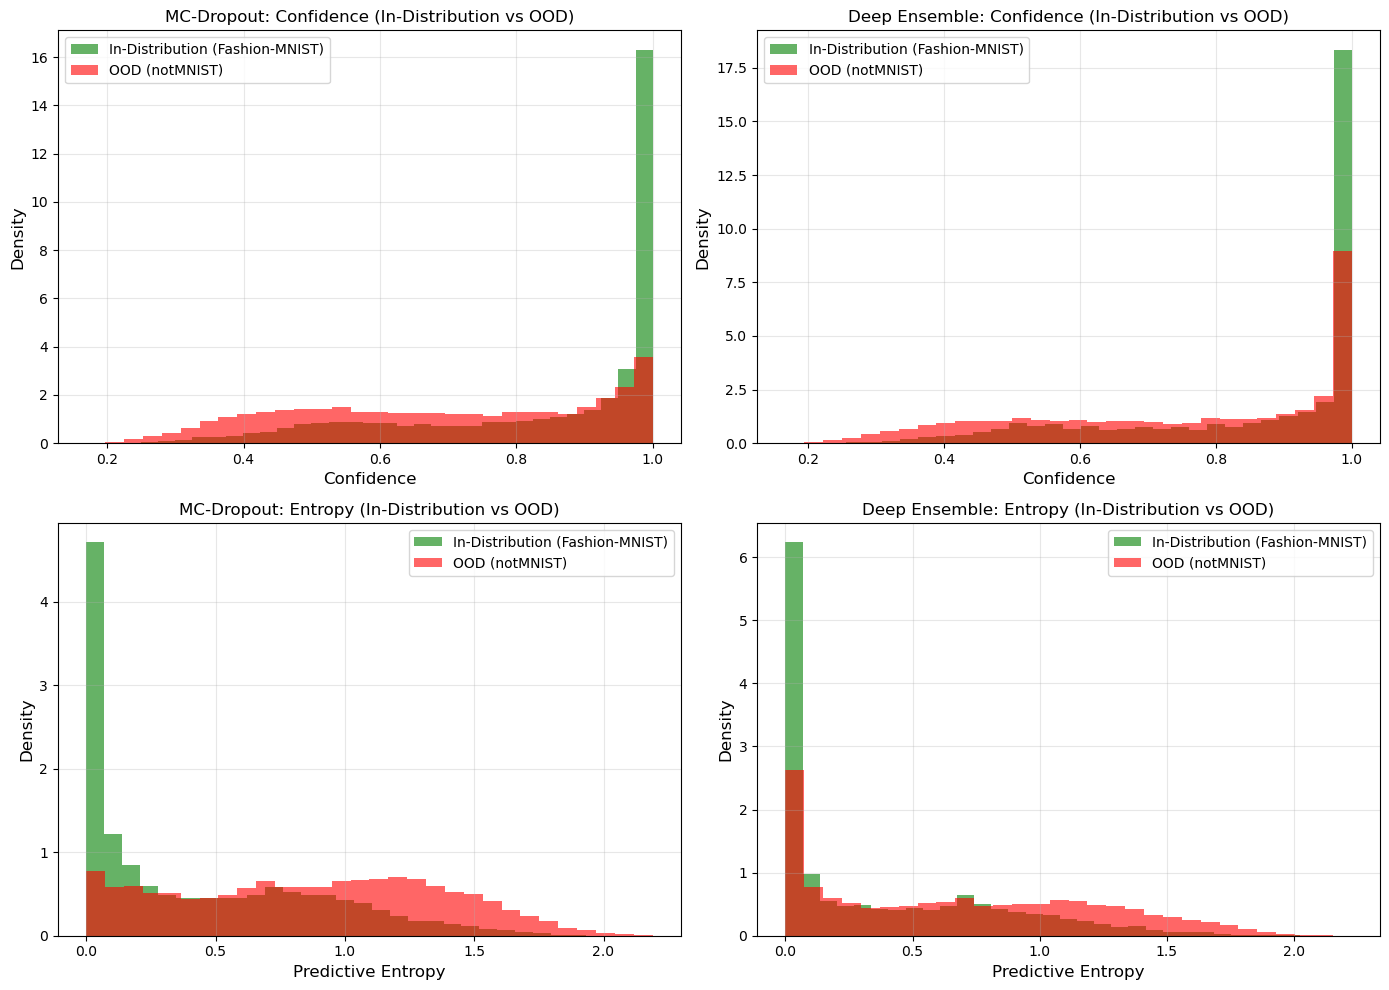

In [31]:

# Task 2d - Plot OOD detection results
# Compare confidence and entropy between in-distribution (Fashion-MNIST) and OOD (notMNIST)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Confidence comparison for MC-Dropout
axes[0, 0].hist(mc_confidences_in, bins=30, alpha=0.6, color='green', 
                label=f'In-Distribution (Fashion-MNIST)', density=True)
axes[0, 0].hist(mc_confidences_ood, bins=30, alpha=0.6, color='red', 
                label=f'OOD (notMNIST)', density=True)
axes[0, 0].set_xlabel('Confidence', fontsize=12)
axes[0, 0].set_ylabel('Density', fontsize=12)
axes[0, 0].set_title('MC-Dropout: Confidence (In-Distribution vs OOD)', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Confidence comparison for Deep Ensemble
axes[0, 1].hist(ensemble_confidences_in, bins=30, alpha=0.6, color='green', 
                label=f'In-Distribution (Fashion-MNIST)', density=True)
axes[0, 1].hist(ensemble_confidences_ood, bins=30, alpha=0.6, color='red', 
                label=f'OOD (notMNIST)', density=True)
axes[0, 1].set_xlabel('Confidence', fontsize=12)
axes[0, 1].set_ylabel('Density', fontsize=12)
axes[0, 1].set_title('Deep Ensemble: Confidence (In-Distribution vs OOD)', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Entropy comparison for MC-Dropout
axes[1, 0].hist(mc_entropies_in, bins=30, alpha=0.6, color='green', 
                label=f'In-Distribution (Fashion-MNIST)', density=True)
axes[1, 0].hist(mc_entropies_ood, bins=30, alpha=0.6, color='red', 
                label=f'OOD (notMNIST)', density=True)
axes[1, 0].set_xlabel('Predictive Entropy', fontsize=12)
axes[1, 0].set_ylabel('Density', fontsize=12)
axes[1, 0].set_title('MC-Dropout: Entropy (In-Distribution vs OOD)', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Entropy comparison for Deep Ensemble
axes[1, 1].hist(ensemble_entropies_in, bins=30, alpha=0.6, color='green', 
                label=f'In-Distribution (Fashion-MNIST)', density=True)
axes[1, 1].hist(ensemble_entropies_ood, bins=30, alpha=0.6, color='red', 
                label=f'OOD (notMNIST)', density=True)
axes[1, 1].set_xlabel('Predictive Entropy', fontsize=12)
axes[1, 1].set_ylabel('Density', fontsize=12)
axes[1, 1].set_title('Deep Ensemble: Entropy (In-Distribution vs OOD)', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/task2d_ood_detection.png', dpi=150, bbox_inches='tight')
plt.show()